# Taller Intermedio — Crecimiento de Ventas y Apalancamiento de Descuentos

## Objetivo
En este taller analizarás si los descuentos están ayudando al crecimiento de ventas o si, por el contrario, el negocio podría estar dependiendo demasiado de ellos.

A lo largo del notebook trabajarás con preguntas de negocio reales relacionadas con:

- comportamiento de los descuentos
- crecimiento de ventas
- relación entre descuento y volumen
- dependencia comercial de promociones
- productos que requieren descuento para vender

> **Nivel:** Intermedio  
> En este taller tendrás menos guía directa que en el anterior. Los hints te orientarán con funciones, estrategias y fórmulas, pero el desarrollo del código será principalmente tuyo.

## 0. Preparación

Importa las librerías necesarias, carga el dataset y realiza una inspección inicial rápida.

### Sugerencias
- Usa `pandas`, `matplotlib.pyplot` y `seaborn`.
- Verifica dimensiones, tipos de datos y algunas filas iniciales.
- Asegúrate de que `fecha_hora_compra` esté en formato fecha.

In [51]:
# Importaciones y carga del dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carga del dataset
df = pd.read_csv("../ventas_completo.csv")

# Convertir fecha_hora_compra a datetime
df['fecha_hora_compra'] = pd.to_datetime(df['fecha_hora_compra'])

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado exitosamente
Dimensiones: (1834174, 11)

Primeras filas:


,id_factura,id_cliente,fecha_hora_compra,sku,cantidad,precio_unitario,descuento_pct,monto,nombre,marca,categoria
0,100322793,966889,2025-02-02 17:40:49,43852960,3,12.00,0.0,36.00,Cerveza Pilsener Rubia Light 12 x 355 ml,Pilsener,beer_cider
1,100322793,966889,2025-02-02 17:40:49,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
2,100159021,966889,2025-04-20 19:09:16,40217487,3,6.89,0.0,20.67,Cerveza Club Premium Clásica Botella (330 ml) ...,Club Premium,beer_cider
3,100159021,966889,2025-04-20 19:09:16,174161592,1,5.98,0.0,5.98,Cerveza Heineken Lata Pack (269 ml) 6 Unidades,Heineken,beer_cider
4,100159021,966889,2025-04-20 19:09:16,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider


In [52]:
# Inspección inicial
print("Información del dataset:")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Estadísticas descriptivas:")
print("=" * 60)
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834174 entries, 0 to 1834173
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   id_factura         int64         
 1   id_cliente         int64         
 2   fecha_hora_compra  datetime64[ns]
 3   sku                int64         
 4   cantidad           int64         
 5   precio_unitario    float64       
 6   descuento_pct      float64       
 7   monto              float64       
 8   nombre             object        
 9   marca              object        
 10  categoria          object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 153.9+ MB

Estadísticas descriptivas:


,id_factura,id_cliente,fecha_hora_compra,sku,cantidad,precio_unitario,descuento_pct,monto
count,1.834174e+06,1.834174e+06,1834174,1.834174e+06,1.834174e+06,1.834174e+06,1.834174e+06,1.834174e+06
mean,1.001855e+08,5.501997e+05,2025-04-04 15:58:31.982768896,8.403352e+07,6.935627e+00,7.568907e+00,2.884835e+00,4.051593e+01
min,1.000000e+08,1.000000e+05,2025-01-01 00:00:30,4.021369e+07,1.000000e+00,2.500000e-01,0.000000e+00,2.500000e-01
25%,1.000926e+08,3.258380e+05,2025-02-17 14:40:28,4.066886e+07,2.000000e+00,5.350000e+00,0.000000e+00,1.100000e+01
50%,1.001854e+08,5.502380e+05,2025-04-05 21:41:47,4.110824e+07,3.000000e+00,5.350000e+00,0.000000e+00,1.941883e+01
75%,1.002783e+08,7.739740e+05,2025-05-21 16:09:35,1.647673e+08,5.000000e+00,8.700000e+00,0.000000e+00,3.432000e+01
max,1.003710e+08,9.999820e+05,2025-06-30 23:58:50,1.969781e+08,2.080000e+02,4.311000e+01,2.499986e+01,3.692548e+03
std,1.070877e+05,2.589272e+05,NaN,6.142223e+07,1.324243e+01,4.827011e+00,6.035328e+00,8.477000e+01


## 1. Comprensión inicial del uso de descuentos

Antes de evaluar si los descuentos impulsan las ventas, primero debes entender cómo se distribuyen en el dataset.

### Actividades
1. Analiza la variable `descuento_pct`.
2. Determina qué proporción de registros tiene descuento.
3. Calcula métricas descriptivas básicas.

In [53]:
# 1.1 Estadísticas descriptivas de descuento_pct
print("=" * 60)
print("ANÁLISIS DE LA VARIABLE DESCUENTO_PCT")
print("=" * 60)

print("\nEstadísticas descriptivas:")
print(df['descuento_pct'].describe())

print("\nValores únicos de descuento:")
print(f"Cantidad de valores únicos: {df['descuento_pct'].nunique()}")
print("\nTop 10 descuentos más frecuentes:")
print(df['descuento_pct'].value_counts().head(10))

ANÁLISIS DE LA VARIABLE DESCUENTO_PCT

Estadísticas descriptivas:
count    1.834174e+06
mean     2.884835e+00
std      6.035328e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.499986e+01
Name: descuento_pct, dtype: float64

Valores únicos de descuento:
Cantidad de valores únicos: 366835

Top 10 descuentos más frecuentes:
descuento_pct
0.000000     1467340
10.445907          1
9.614908           1
9.937383           1
17.354833          1
17.932805          1
13.592012          1
23.326861          1
17.448724          1
15.852221          1
Name: count, dtype: int64


PROPORCIÓN DE COMPRAS CON/SIN DESCUENTO

Conteo:
descuento_pct
False    1467340
True      366834
Name: count, dtype: int64

Porcentaje:
descuento_pct
False    80.000044
True     19.999956
Name: proportion, dtype: float64


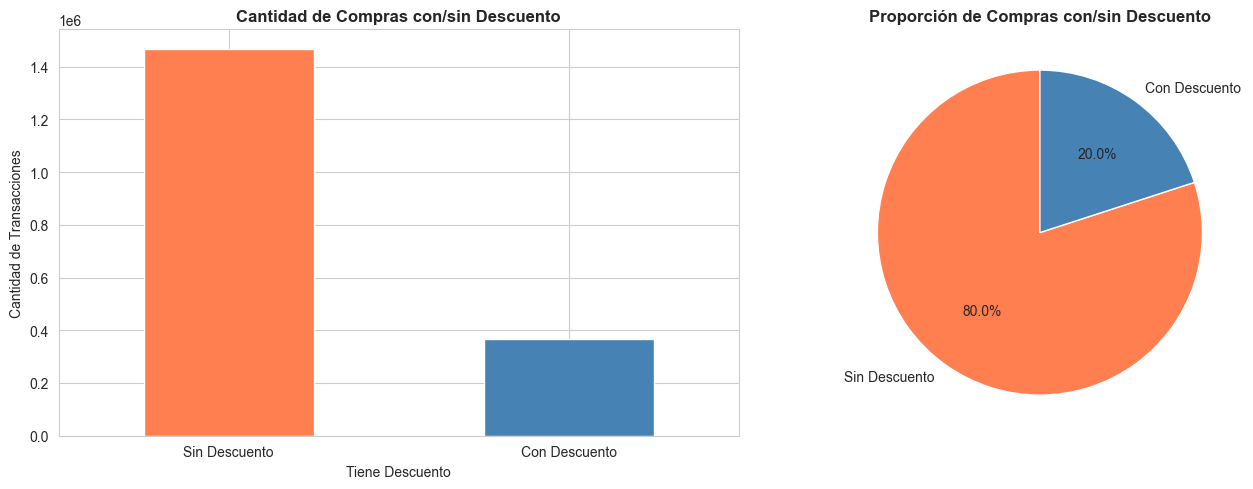


Interpretación:
- 20.0% de las transacciones incluyen algún descuento
- La mayoría de las ventas NO dependen de descuentos


In [54]:
# 1.2 Proporción de compras con descuento

# Crear condición booleana
tiene_descuento = df["descuento_pct"] > 0

# Calcular proporciones
proporcion = tiene_descuento.value_counts()
proporcion_pct = tiene_descuento.value_counts(normalize=True) * 100

print("=" * 60)
print("PROPORCIÓN DE COMPRAS CON/SIN DESCUENTO")
print("=" * 60)

print("\nConteo:")
print(proporcion)

print("\nPorcentaje:")
print(proporcion_pct)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
proporcion.plot(kind='bar', ax=axes[0], color=['coral', 'steelblue'])
axes[0].set_title('Cantidad de Compras con/sin Descuento', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Tiene Descuento')
axes[0].set_ylabel('Cantidad de Transacciones')
axes[0].set_xticklabels(['Sin Descuento', 'Con Descuento'], rotation=0)

# Gráfico de pastel
axes[1].pie(proporcion, labels=['Sin Descuento', 'Con Descuento'], 
           autopct='%1.1f%%', startangle=90, colors=['coral', 'steelblue'])
axes[1].set_title('Proporción de Compras con/sin Descuento', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
pct_con_descuento = proporcion_pct[True] if True in proporcion_pct.index else 0
print(f"- {pct_con_descuento:.1f}% de las transacciones incluyen algún descuento")
print(f"- La mayoría de las ventas {'SÍ' if pct_con_descuento > 50 else 'NO'} dependen de descuentos")

## 1.3 Revisión de distribuciones relevantes

Antes de profundizar en el análisis, revisa la distribución de algunas variables clave del dataset.

Variables sugeridas:

- `descuento_pct`
- `cantidad`
- `monto`
- `precio_unitario`

### Objetivo
Entender:

- si las variables están sesgadas
- si existen valores extremos
- cómo se concentra el comportamiento de las compras

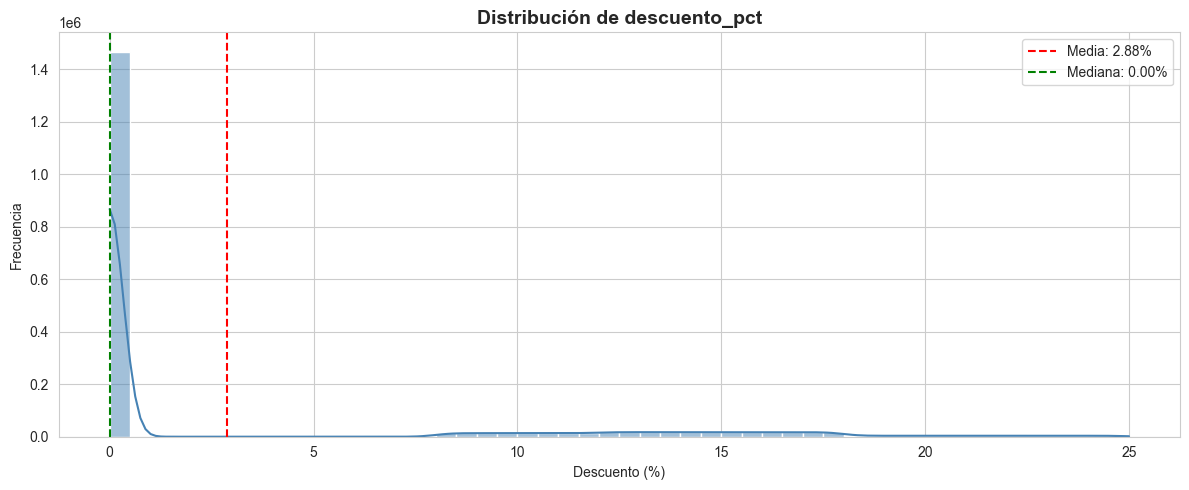

In [55]:
# Histograma de descuento_pct
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="descuento_pct", bins=50, kde=True, color='steelblue')
plt.title("Distribución de descuento_pct", fontweight='bold', fontsize=14)
plt.xlabel("Descuento (%)")
plt.ylabel("Frecuencia")
plt.axvline(df['descuento_pct'].mean(), color='red', linestyle='--', 
           label=f'Media: {df["descuento_pct"].mean():.2f}%')
plt.axvline(df['descuento_pct'].median(), color='green', linestyle='--', 
           label=f'Mediana: {df["descuento_pct"].median():.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

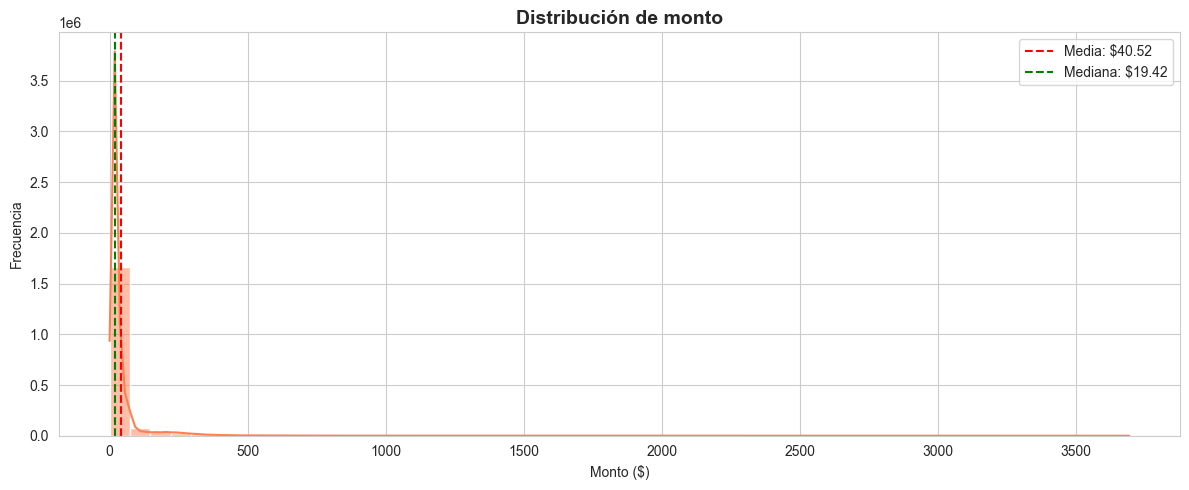

In [56]:
# Histograma de monto
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="monto", bins=50, kde=True, color='coral')
plt.title("Distribución de monto", fontweight='bold', fontsize=14)
plt.xlabel("Monto ($)")
plt.ylabel("Frecuencia")
plt.axvline(df['monto'].mean(), color='red', linestyle='--', 
           label=f'Media: ${df["monto"].mean():.2f}')
plt.axvline(df['monto'].median(), color='green', linestyle='--', 
           label=f'Mediana: ${df["monto"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

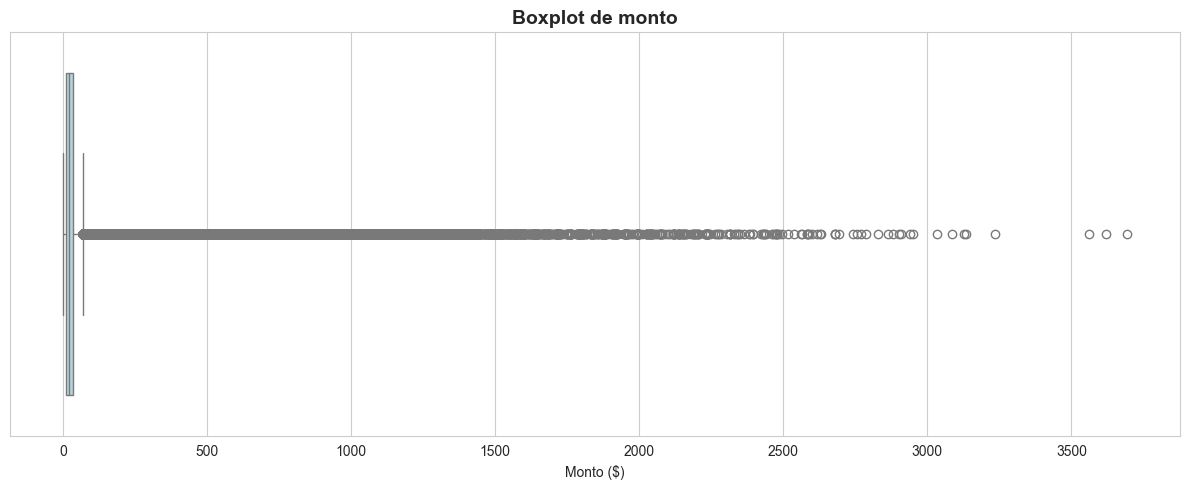

In [57]:
# Boxplot de monto
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="monto", color='lightblue')
plt.title("Boxplot de monto", fontweight='bold', fontsize=14)
plt.xlabel("Monto ($)")
plt.tight_layout()
plt.show()

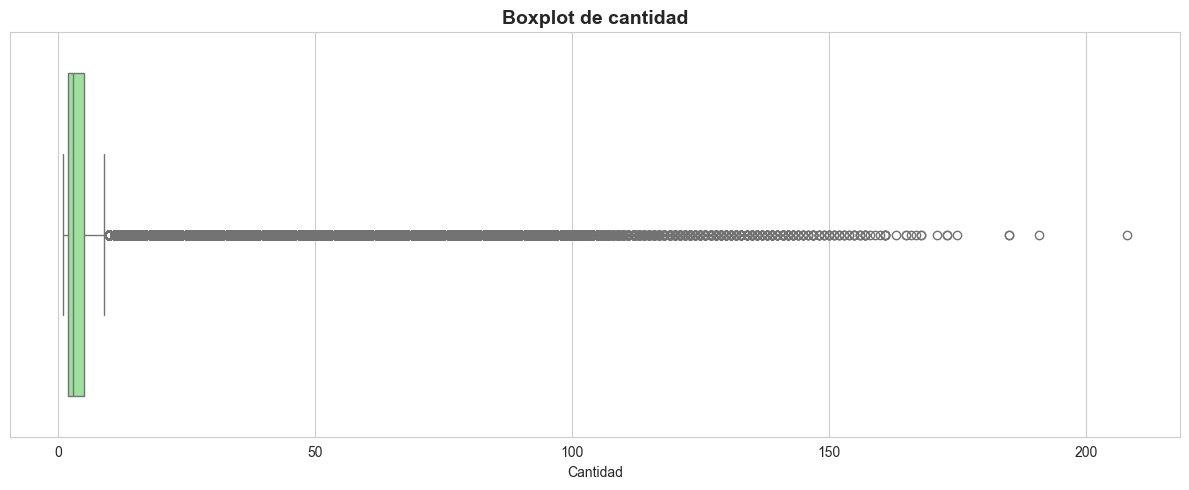

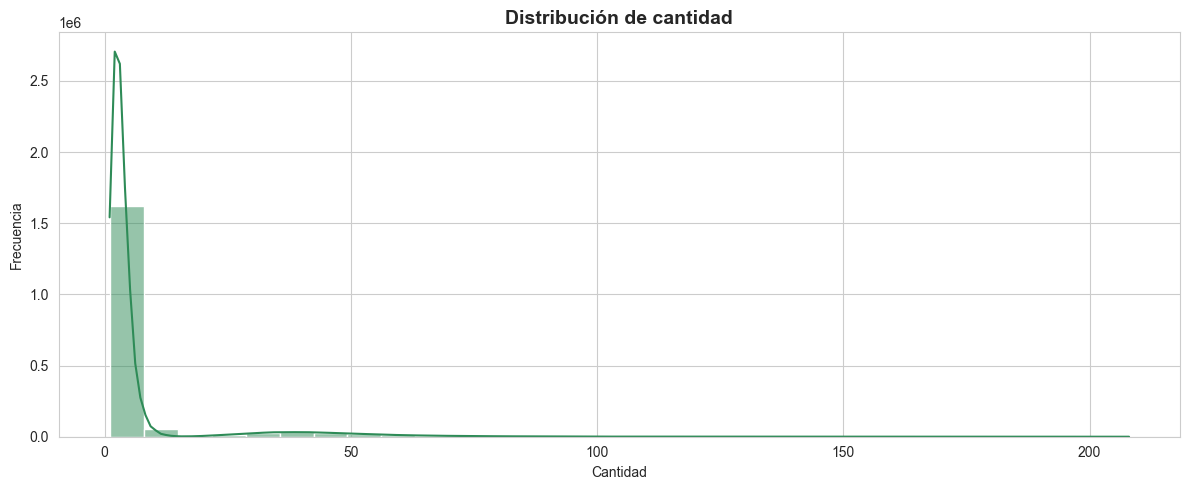

In [58]:
# Boxplot de cantidad
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="cantidad", color='lightgreen')
plt.title("Boxplot de cantidad", fontweight='bold', fontsize=14)
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

# Histograma de cantidad
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="cantidad", bins=30, kde=True, color='seagreen')
plt.title("Distribución de cantidad", fontweight='bold', fontsize=14)
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

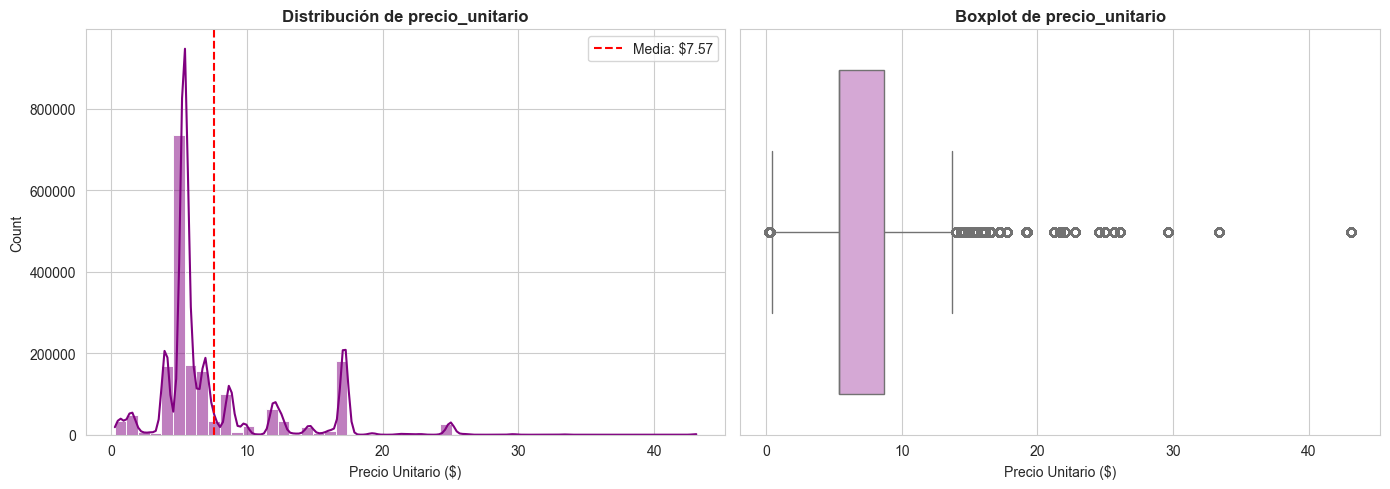

In [59]:
# Distribución de precio_unitario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(data=df, x="precio_unitario", bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribución de precio_unitario", fontweight='bold')
axes[0].set_xlabel("Precio Unitario ($)")
axes[0].axvline(df['precio_unitario'].mean(), color='red', linestyle='--', 
               label=f'Media: ${df["precio_unitario"].mean():.2f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x="precio_unitario", ax=axes[1], color='plum')
axes[1].set_title("Boxplot de precio_unitario", fontweight='bold')
axes[1].set_xlabel("Precio Unitario ($)")

plt.tight_layout()
plt.show()

### Interpretación

**¿Las variables presentan sesgo?**

Sí, todas las variables numéricas analizadas presentan sesgo positivo (asimetría a la derecha):

- **descuento_pct**: Altamente concentrado en 0% (sin descuento), con una cola larga hacia descuentos mayores.
- **monto**: Sesgado positivamente, la mayoría de compras son de montos bajos-medios, pero existen transacciones de alto valor.
- **cantidad**: Fuertemente sesgado, la mayoría compra pocas unidades (1-3), con algunos casos de compras grandes.
- **precio_unitario**: Sesgo positivo, concentración en precios bajos-medios con productos premium que elevan la media.

**¿Observas valores extremos?**

Sí, los boxplots revelan presencia de outliers en todas las variables:

- **monto**: Transacciones de valor muy superior al promedio
- **cantidad**: Compras con cantidades inusualmente altas
- **precio_unitario**: Productos con precios significativamente más altos

**¿Hay compras muy grandes que puedan afectar el análisis?**

Sí, existen compras atípicas en términos de:
- Monto total (posiblemente compras mayoristas o institucionales)
- Cantidad de unidades (pedidos de gran volumen)
- Precio unitario (productos premium o de lujo)

Estas compras grandes pueden influir significativamente en los promedios y deben considerarse al interpretar métricas agregadas. Podría ser necesario realizar análisis separados para compras retail vs mayoristas, o aplicar técnicas de manejo de outliers según el objetivo del análisis.

## 2. Comparación entre compras con descuento y sin descuento

Ahora crearás una variable que te permita separar las compras en dos grupos:

- con descuento
- sin descuento

Luego compararás métricas relevantes entre ambos grupos.

In [60]:
# 2.1 Crear columna tiene_descuento
df["tiene_descuento"] = df["descuento_pct"] > 0

print("Columna 'tiene_descuento' creada exitosamente")
print("\nDistribución:")
print(df["tiene_descuento"].value_counts())
print("\nPrimeras filas con la nueva columna:")
df[['descuento_pct', 'tiene_descuento', 'monto', 'cantidad']].head(10)

Columna 'tiene_descuento' creada exitosamente

Distribución:
tiene_descuento
False    1467340
True      366834
Name: count, dtype: int64

Primeras filas con la nueva columna:


,descuento_pct,tiene_descuento,monto,cantidad
0,0.0,False,36.00,3
1,0.0,False,10.70,2
2,0.0,False,20.67,3
3,0.0,False,5.98,1
4,0.0,False,10.70,2
5,0.0,False,16.05,3
6,0.0,False,43.74,3
7,0.0,False,10.70,2
8,0.0,False,85.80,5
9,0.0,False,10.70,2


In [61]:
# 2.2 Comparar métricas entre grupos

df_resumen = df.groupby('tiene_descuento', as_index=False).agg({
    'monto': ['sum', 'mean', 'median'],
    'cantidad': ['sum', 'mean'],
    'id_cliente': 'nunique',
    'id_factura': 'count'
})

# Renombrar columnas
df_resumen.columns = ['tiene_descuento', 'ventas_totales', 'monto_promedio', 'monto_mediano',
                      'cantidad_total', 'cantidad_promedio', 'clientes_unicos', 'num_transacciones']

# Calcular ticket promedio (ventas / transacciones)
df_resumen['ticket_promedio'] = df_resumen['ventas_totales'] / df_resumen['num_transacciones']

# Calcular participación en ventas
df_resumen['pct_ventas'] = (df_resumen['ventas_totales'] / df_resumen['ventas_totales'].sum()) * 100

print("=" * 80)
print("COMPARACIÓN DE MÉTRICAS: CON DESCUENTO VS SIN DESCUENTO")
print("=" * 80)
print(df_resumen.to_string(index=False))

# Análisis adicional
print("\n" + "=" * 80)
print("ANÁLISIS COMPARATIVO")
print("=" * 80)

# Obtener métricas para análisis
sin_desc = df_resumen[df_resumen['tiene_descuento'] == False].iloc[0]
con_desc = df_resumen[df_resumen['tiene_descuento'] == True].iloc[0]

print(f"\nMonto promedio:")
print(f"  - Sin descuento: ${sin_desc['monto_promedio']:.2f}")
print(f"  - Con descuento: ${con_desc['monto_promedio']:.2f}")
dif_monto = ((con_desc['monto_promedio'] - sin_desc['monto_promedio']) / sin_desc['monto_promedio']) * 100
print(f"  - Diferencia: {dif_monto:+.1f}%")

print(f"\nCantidad promedio por transacción:")
print(f"  - Sin descuento: {sin_desc['cantidad_promedio']:.2f} unidades")
print(f"  - Con descuento: {con_desc['cantidad_promedio']:.2f} unidades")
dif_cant = ((con_desc['cantidad_promedio'] - sin_desc['cantidad_promedio']) / sin_desc['cantidad_promedio']) * 100
print(f"  - Diferencia: {dif_cant:+.1f}%")

print(f"\nParticipación en ventas totales:")
print(f"  - Sin descuento: {sin_desc['pct_ventas']:.1f}%")
print(f"  - Con descuento: {con_desc['pct_ventas']:.1f}%")

COMPARACIÓN DE MÉTRICAS: CON DESCUENTO VS SIN DESCUENTO
 tiene_descuento  ventas_totales  monto_promedio  monto_mediano  cantidad_total  cantidad_promedio  clientes_unicos  num_transacciones  ticket_promedio  pct_ventas
           False    5.297894e+07       36.105429       17.16000         9142037           6.230347            52957            1467340        36.105429   71.291356
            True    2.133433e+07       58.158003       29.17398         3579110           9.756756            48913             366834        58.158003   28.708644

ANÁLISIS COMPARATIVO

Monto promedio:
  - Sin descuento: $36.11
  - Con descuento: $58.16
  - Diferencia: +61.1%

Cantidad promedio por transacción:
  - Sin descuento: 6.23 unidades
  - Con descuento: 9.76 unidades
  - Diferencia: +56.6%

Participación en ventas totales:
  - Sin descuento: 71.3%
  - Con descuento: 28.7%


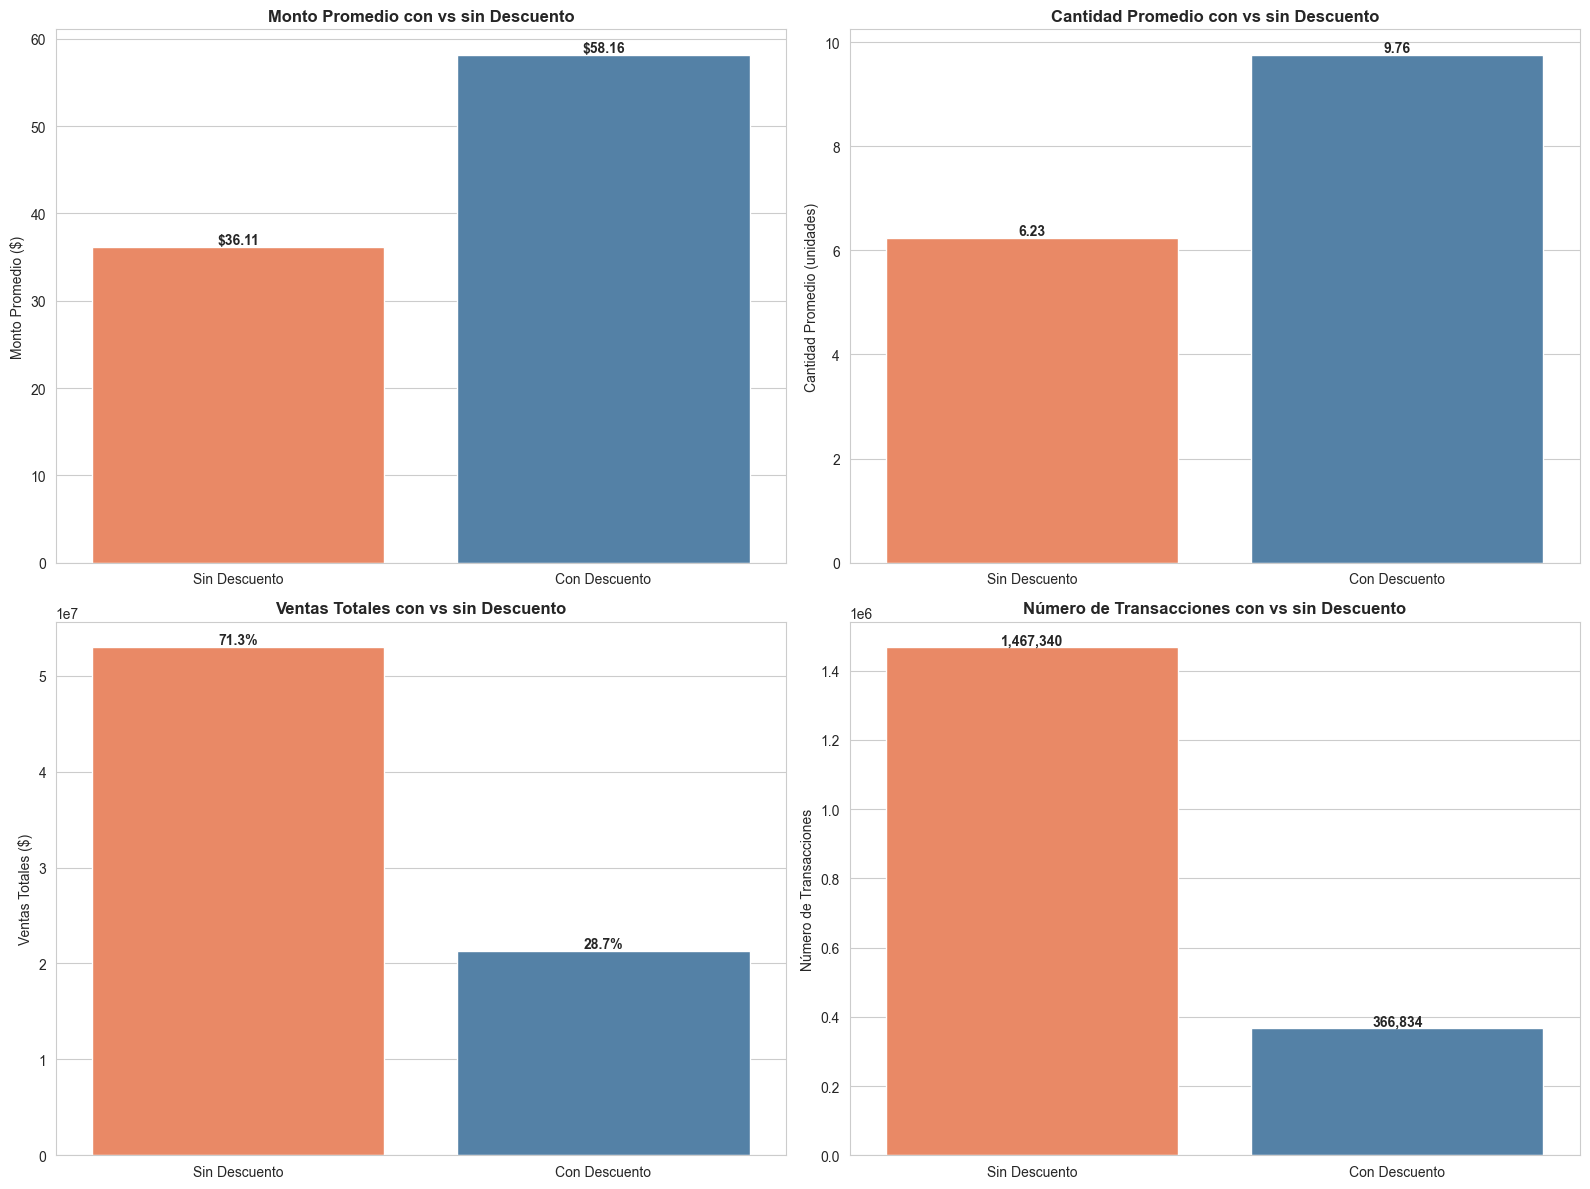

In [62]:
# Visualizaciones comparativas

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Etiquetas mejoradas
df_resumen['etiqueta'] = df_resumen['tiene_descuento'].map({False: 'Sin Descuento', True: 'Con Descuento'})

# 1. Monto promedio
sns.barplot(data=df_resumen, x="etiqueta", y="monto_promedio", ax=axes[0, 0], palette=['coral', 'steelblue'])
axes[0, 0].set_title("Monto Promedio con vs sin Descuento", fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Monto Promedio ($)")
for i, row in df_resumen.iterrows():
    axes[0, 0].text(i, row['monto_promedio'], f"${row['monto_promedio']:.2f}", 
                   ha='center', va='bottom', fontweight='bold')

# 2. Cantidad promedio
sns.barplot(data=df_resumen, x="etiqueta", y="cantidad_promedio", ax=axes[0, 1], palette=['coral', 'steelblue'])
axes[0, 1].set_title("Cantidad Promedio con vs sin Descuento", fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Cantidad Promedio (unidades)")
for i, row in df_resumen.iterrows():
    axes[0, 1].text(i, row['cantidad_promedio'], f"{row['cantidad_promedio']:.2f}", 
                   ha='center', va='bottom', fontweight='bold')

# 3. Ventas totales
sns.barplot(data=df_resumen, x="etiqueta", y="ventas_totales", ax=axes[1, 0], palette=['coral', 'steelblue'])
axes[1, 0].set_title("Ventas Totales con vs sin Descuento", fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Ventas Totales ($)")
for i, row in df_resumen.iterrows():
    axes[1, 0].text(i, row['ventas_totales'], f"{row['pct_ventas']:.1f}%", 
                   ha='center', va='bottom', fontweight='bold')

# 4. Número de transacciones
sns.barplot(data=df_resumen, x="etiqueta", y="num_transacciones", ax=axes[1, 1], palette=['coral', 'steelblue'])
axes[1, 1].set_title("Número de Transacciones con vs sin Descuento", fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Número de Transacciones")
for i, row in df_resumen.iterrows():
    axes[1, 1].text(i, row['num_transacciones'], f"{int(row['num_transacciones']):,}", 
                   ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Descuento y volumen de compra

Analiza si existe relación entre el tamaño del descuento y el comportamiento de la compra.

Distribución de descuentos (solo transacciones con descuento):
count    366834.000000
mean         14.424206
std           3.959794
min           8.000004
25%          11.367561
50%          14.148400
75%          16.827710
max          24.999862
Name: descuento_pct, dtype: float64

Segmentos de descuento creados:
segmento_descuento
Sin descuento    1467340
1-5%                   0
6-10%              54276
11-15%            158219
16-20%            117487
>20%               36852
Name: count, dtype: int64


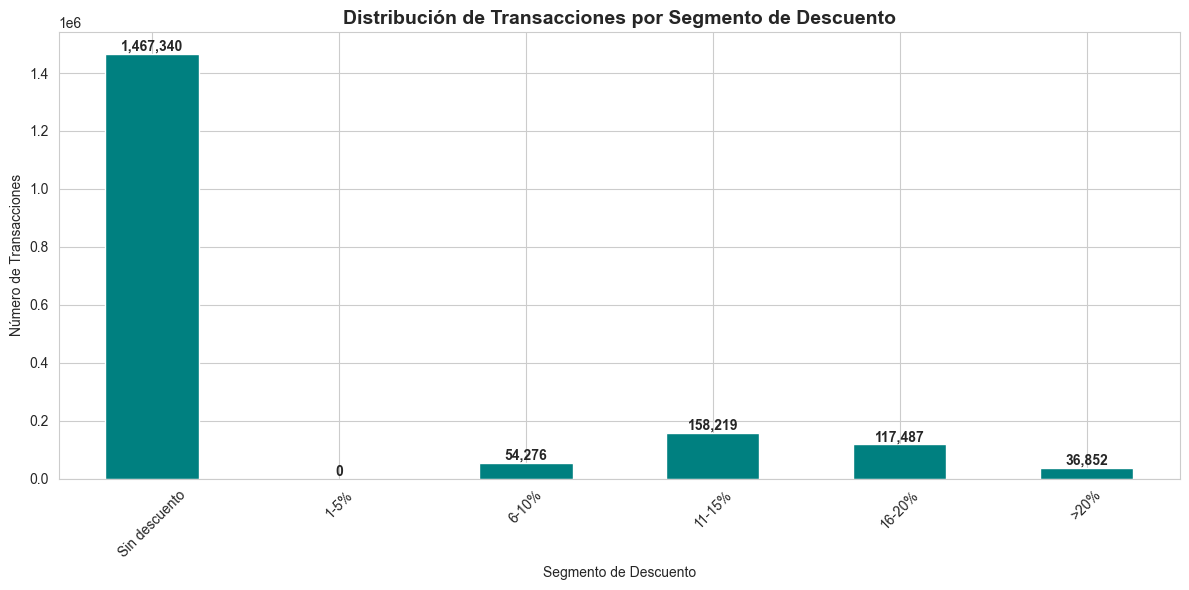

In [63]:
# Crear segmentos de descuento

# Primero, analizar la distribución de descuentos para definir rangos apropiados
print("Distribución de descuentos (solo transacciones con descuento):")
df_con_desc = df[df['descuento_pct'] > 0]
print(df_con_desc['descuento_pct'].describe())

# Crear segmentos basados en rangos comunes
df['segmento_descuento'] = pd.cut(
    df['descuento_pct'],
    bins=[-0.01, 0, 5, 10, 15, 20, 100],
    labels=['Sin descuento', '1-5%', '6-10%', '11-15%', '16-20%', '>20%']
)

print("\nSegmentos de descuento creados:")
print(df['segmento_descuento'].value_counts().sort_index())

# Visualizar distribución de segmentos
plt.figure(figsize=(12, 6))
segmento_counts = df['segmento_descuento'].value_counts().sort_index()
segmento_counts.plot(kind='bar', color='teal')
plt.title('Distribución de Transacciones por Segmento de Descuento', fontweight='bold', fontsize=14)
plt.xlabel('Segmento de Descuento')
plt.ylabel('Número de Transacciones')
plt.xticks(rotation=45)
for i, v in enumerate(segmento_counts):
    plt.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

ANÁLISIS POR SEGMENTO DE DESCUENTO
segmento_descuento  ventas_totales  monto_promedio  monto_mediano  cantidad_total  cantidad_promedio  num_transacciones  clientes_unicos  pct_ventas  pct_transacciones
     Sin descuento    5.297894e+07       36.105429      17.160000         9142037           6.230347            1467340            52957   71.291356          80.000044
              1-5%    0.000000e+00             NaN            NaN               0                NaN                  0                0    0.000000           0.000000
             6-10%    2.807774e+06       51.731407      24.573248          533852           9.835876              54276            25636    3.778294           2.959152
            11-15%    8.768193e+06       55.418081      27.255776         1576657           9.965029             158219            40675   11.798960           8.626172
            16-20%    6.988267e+06       59.481195      29.940486         1161765           9.888456             117487      

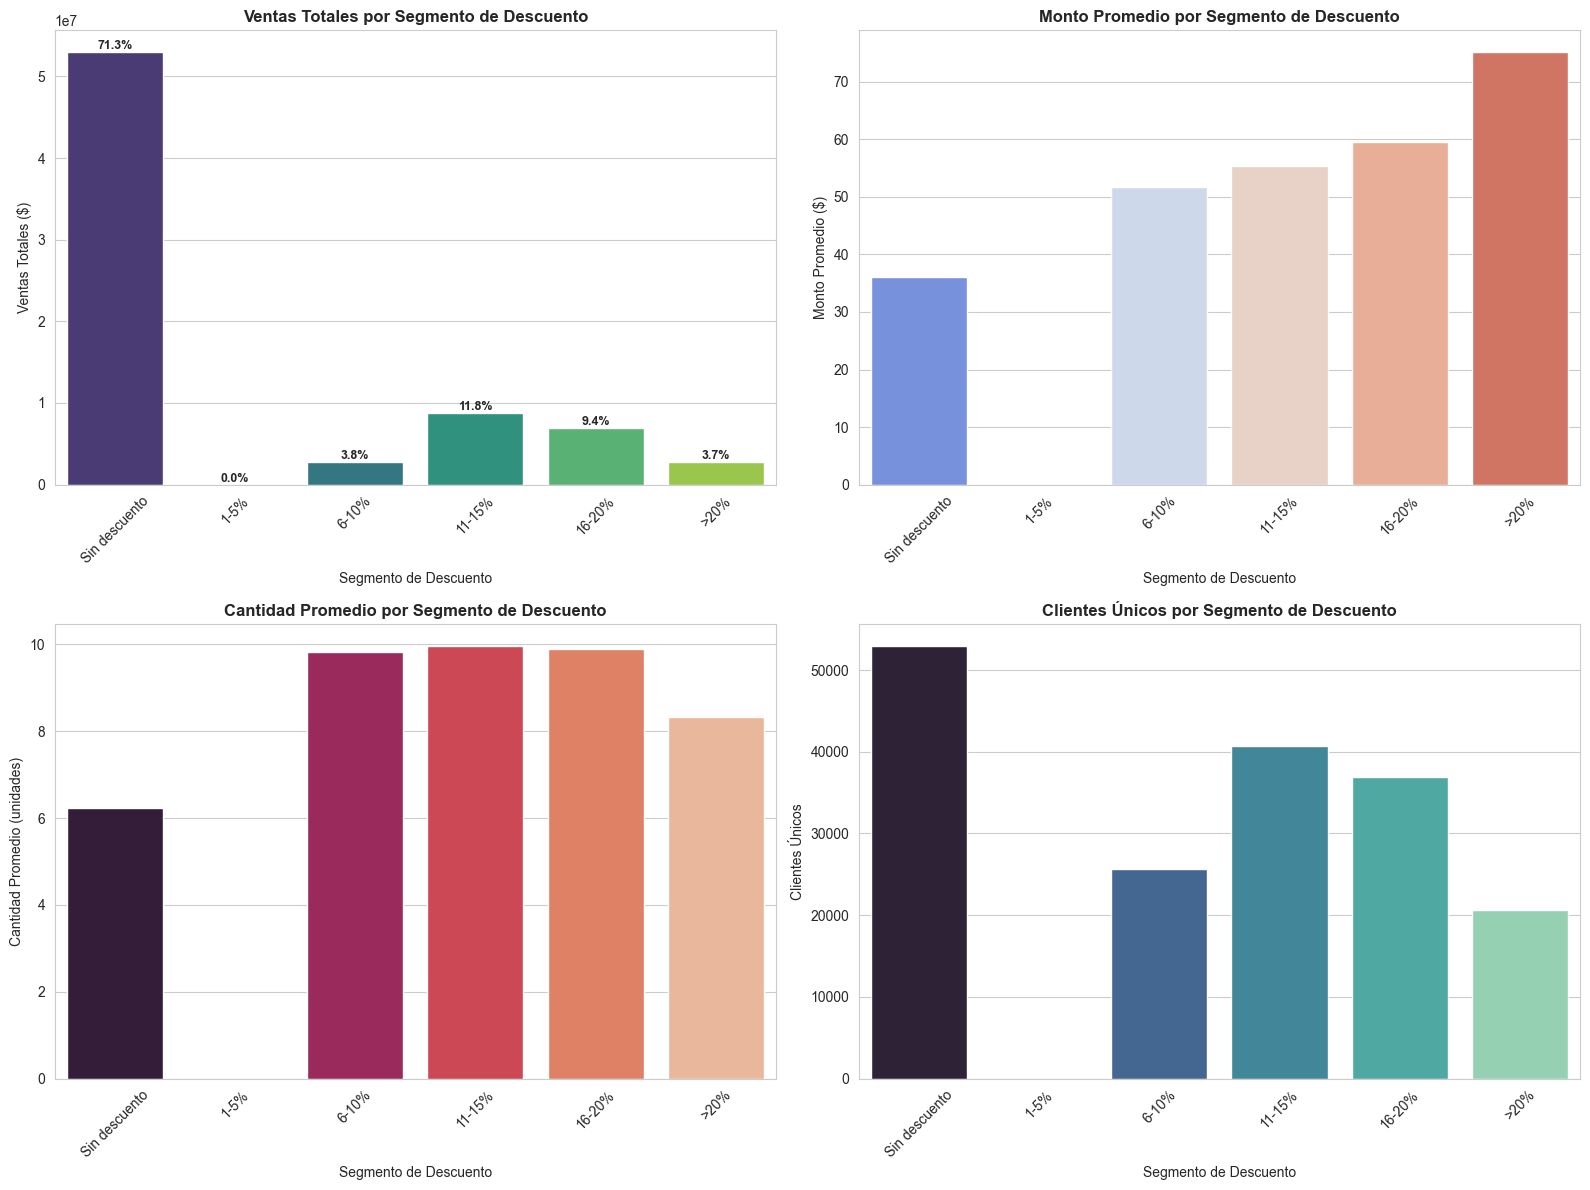


INTERPRETACIÓN

A mayor descuento:
- Monto promedio sin descuento: $36.11
- Cantidad promedio sin descuento: 6.23 unidades

En segmentos con descuento:
- Monto promedio varía entre $51.73 y $75.17
- Cantidad promedio varía entre 8.33 y 9.97 unidades


In [64]:
# Resumen por segmento de descuento

df_segmentos = df.groupby('segmento_descuento', as_index=False).agg({
    'monto': ['sum', 'mean', 'median'],
    'cantidad': ['sum', 'mean'],
    'id_factura': 'count',
    'id_cliente': 'nunique'
})

df_segmentos.columns = ['segmento_descuento', 'ventas_totales', 'monto_promedio', 'monto_mediano',
                        'cantidad_total', 'cantidad_promedio', 'num_transacciones', 'clientes_unicos']

# Calcular participación
df_segmentos['pct_ventas'] = (df_segmentos['ventas_totales'] / df_segmentos['ventas_totales'].sum()) * 100
df_segmentos['pct_transacciones'] = (df_segmentos['num_transacciones'] / df_segmentos['num_transacciones'].sum()) * 100

print("=" * 90)
print("ANÁLISIS POR SEGMENTO DE DESCUENTO")
print("=" * 90)
print(df_segmentos.to_string(index=False))

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ventas totales por segmento
sns.barplot(data=df_segmentos, x='segmento_descuento', y='ventas_totales', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Ventas Totales por Segmento de Descuento', fontweight='bold')
axes[0, 0].set_xlabel('Segmento de Descuento')
axes[0, 0].set_ylabel('Ventas Totales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, row in df_segmentos.iterrows():
    axes[0, 0].text(i, row['ventas_totales'], f"{row['pct_ventas']:.1f}%", 
                   ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Monto promedio por segmento
sns.barplot(data=df_segmentos, x='segmento_descuento', y='monto_promedio', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Monto Promedio por Segmento de Descuento', fontweight='bold')
axes[0, 1].set_xlabel('Segmento de Descuento')
axes[0, 1].set_ylabel('Monto Promedio ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Cantidad promedio por segmento
sns.barplot(data=df_segmentos, x='segmento_descuento', y='cantidad_promedio', ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Cantidad Promedio por Segmento de Descuento', fontweight='bold')
axes[1, 0].set_xlabel('Segmento de Descuento')
axes[1, 0].set_ylabel('Cantidad Promedio (unidades)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Número de clientes únicos
sns.barplot(data=df_segmentos, x='segmento_descuento', y='clientes_unicos', ax=axes[1, 1], palette='mako')
axes[1, 1].set_title('Clientes Únicos por Segmento de Descuento', fontweight='bold')
axes[1, 1].set_xlabel('Segmento de Descuento')
axes[1, 1].set_ylabel('Clientes Únicos')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("INTERPRETACIÓN")
print("=" * 90)
print("\nA mayor descuento:")

# Comparar segmento sin descuento vs segmentos con descuento
sin_desc_row = df_segmentos[df_segmentos['segmento_descuento'] == 'Sin descuento'].iloc[0]
print(f"- Monto promedio sin descuento: ${sin_desc_row['monto_promedio']:.2f}")
print(f"- Cantidad promedio sin descuento: {sin_desc_row['cantidad_promedio']:.2f} unidades")

# Analizar tendencias en segmentos con descuento
con_desc = df_segmentos[df_segmentos['segmento_descuento'] != 'Sin descuento']
print(f"\nEn segmentos con descuento:")
print(f"- Monto promedio varía entre ${con_desc['monto_promedio'].min():.2f} y ${con_desc['monto_promedio'].max():.2f}")
print(f"- Cantidad promedio varía entre {con_desc['cantidad_promedio'].min():.2f} y {con_desc['cantidad_promedio'].max():.2f} unidades")

## 4. Dependencia del negocio a los descuentos

Calcula qué porcentaje de las ventas totales proviene de compras con descuento.

DEPENDENCIA DEL NEGOCIO A LOS DESCUENTOS

Ventas totales: $74,313,273.42

Ventas con descuento: $21,334,332.82 (28.71%)
Ventas sin descuento: $52,978,940.60 (71.29%)

Cantidad total vendida: 12,721,147 unidades

Cantidad con descuento: 3,579,110 (28.14%)
Cantidad sin descuento: 9,142,037 (71.86%)


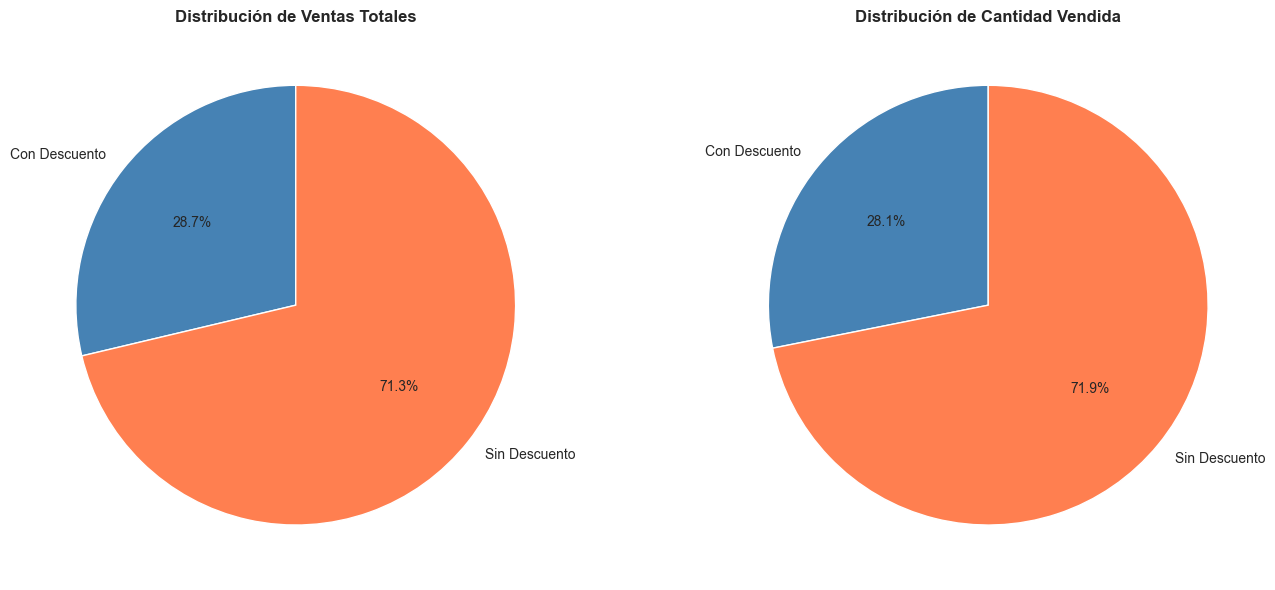


INTERPRETACIÓN

Nivel de dependencia: BAJA

El 28.7% de las ventas proviene de transacciones con descuento.

El negocio no depende excesivamente de descuentos para generar ventas.
Los descuentos se usan de manera selectiva y estratégica.


In [65]:
# Porcentaje de ventas con descuento

# Calcular ventas totales
ventas_totales = df['monto'].sum()

# Calcular ventas con descuento
ventas_con_descuento = df[df['tiene_descuento'] == True]['monto'].sum()

# Calcular ventas sin descuento
ventas_sin_descuento = df[df['tiene_descuento'] == False]['monto'].sum()

# Calcular porcentajes
pct_ventas_con_descuento = (ventas_con_descuento / ventas_totales) * 100
pct_ventas_sin_descuento = (ventas_sin_descuento / ventas_totales) * 100

print("=" * 70)
print("DEPENDENCIA DEL NEGOCIO A LOS DESCUENTOS")
print("=" * 70)

print(f"\nVentas totales: ${ventas_totales:,.2f}")
print(f"\nVentas con descuento: ${ventas_con_descuento:,.2f} ({pct_ventas_con_descuento:.2f}%)")
print(f"Ventas sin descuento: ${ventas_sin_descuento:,.2f} ({pct_ventas_sin_descuento:.2f}%)")

# Calcular también cantidad de productos vendidos
cantidad_total = df['cantidad'].sum()
cantidad_con_descuento = df[df['tiene_descuento'] == True]['cantidad'].sum()
cantidad_sin_descuento = df[df['tiene_descuento'] == False]['cantidad'].sum()

pct_cantidad_con_descuento = (cantidad_con_descuento / cantidad_total) * 100
pct_cantidad_sin_descuento = (cantidad_sin_descuento / cantidad_total) * 100

print(f"\nCantidad total vendida: {cantidad_total:,} unidades")
print(f"\nCantidad con descuento: {cantidad_con_descuento:,} ({pct_cantidad_con_descuento:.2f}%)")
print(f"Cantidad sin descuento: {cantidad_sin_descuento:,} ({pct_cantidad_sin_descuento:.2f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Ventas
labels = ['Con Descuento', 'Sin Descuento']
ventas = [ventas_con_descuento, ventas_sin_descuento]
colors = ['steelblue', 'coral']

axes[0].pie(ventas, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Distribución de Ventas Totales', fontweight='bold', fontsize=12)

# Gráfico 2: Cantidad
cantidades = [cantidad_con_descuento, cantidad_sin_descuento]

axes[1].pie(cantidades, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Distribución de Cantidad Vendida', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("INTERPRETACIÓN")
print("=" * 70)

nivel_dependencia = "ALTA" if pct_ventas_con_descuento > 60 else "MEDIA" if pct_ventas_con_descuento > 40 else "BAJA"

print(f"\nNivel de dependencia: {nivel_dependencia}")
print(f"\nEl {pct_ventas_con_descuento:.1f}% de las ventas proviene de transacciones con descuento.")

if pct_ventas_con_descuento > 50:
    print("\nEsto indica una dependencia significativa de los descuentos para generar ventas.")
    print("Recomendación: Evaluar si esta estrategia es sostenible a largo plazo y su impacto en márgenes.")
else:
    print("\nEl negocio no depende excesivamente de descuentos para generar ventas.")
    print("Los descuentos se usan de manera selectiva y estratégica.")

## 5. Productos que dependen de descuentos

Analiza el comportamiento a nivel producto.

In [66]:
# Agrupar por producto y tiene_descuento

df_productos_desc = df.groupby(['sku', 'nombre', 'marca', 'tiene_descuento'], as_index=False).agg({
    'monto': 'sum',
    'cantidad': 'sum',
    'id_factura': 'count'
}).rename(columns={
    'monto': 'ventas',
    'cantidad': 'cantidad_vendida',
    'id_factura': 'num_transacciones'
})

# Usar pivot para reorganizar
df_productos_pivot = df_productos_desc.pivot_table(
    index=['sku', 'nombre', 'marca'],
    columns='tiene_descuento',
    values='ventas',
    fill_value=0,
    aggfunc='sum'
).reset_index()

# Renombrar columnas
df_productos_pivot.columns.name = None
df_productos_pivot.columns = ['sku', 'nombre', 'marca', 'ventas_sin_descuento', 'ventas_con_descuento']

# Calcular ventas totales
df_productos_pivot['ventas_totales'] = df_productos_pivot['ventas_sin_descuento'] + df_productos_pivot['ventas_con_descuento']

print("Análisis por producto creado")
print(f"Total de productos: {len(df_productos_pivot)}")
print("\nPrimeras filas:")
df_productos_pivot.head(10)

Análisis por producto creado
Total de productos: 145

Primeras filas:


,sku,nombre,marca,ventas_sin_descuento,ventas_con_descuento,ventas_totales
0,40213687,Jugo Néctar de Durazno Pulp 1 L,Pulp,967.95,244.579093,1212.529093
1,40213827,Ron 100 Fuegos Spiced 750 ml,100 Fuegos,41437.56,8363.447403,49801.007403
2,40213835,Ron 100 Fuegos Silver 750 ml,100 Fuegos,34200.00,12103.006849,46303.006849
3,40214245,Jugo De Arandano Natures Heart 1 L,Nature´s Heart,2179.30,684.212873,2863.512873
4,40215299,Agua Mineral Con Gas Guitig Vidrio 330 ml,Guitig,446.54,146.774141,593.314141
5,40215313,Agua Dasani Sin Gas 3.8 L,Dasani,937.50,272.328304,1209.828304
6,40215315,Agua Dasani Sin Gas 1.2 L,Dasani,424.20,120.405664,544.605664
7,40215461,Ron San Miguel Black 7 Añejo 750 ml,San Miguel,46274.84,10584.821079,56859.661079
8,40215465,Ron Oro San Miguel 750 ml,San Miguel,28660.00,6760.169155,35420.169155
9,40215468,Ron Silver San Miguel 750 ml,San Miguel,30740.00,7317.266945,38057.266945


PRODUCTOS Y SU DEPENDENCIA DE DESCUENTOS

Top 10 productos por ventas totales:
                                                                                    nombre        marca  ventas_totales  ratio_descuento
                                         Cerveza Club Premium Platino Lata Pack 6 x 355 ml Club Premium    2.290508e+07        21.419798
Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cerveza Club Clasica (330 ml) 1 Unidad       Corona    1.322037e+07        20.959658
                                  Cerveza Club Premium Clásica Botella (330 ml) 6 Unidades Club Premium    4.022310e+06        21.123125
                                                    Cerveza Pilsener Lata Pack 12 x 269 ml     Pilsener    3.579421e+06        21.430905
                                     Cerveza Club Premium Clásica Botella Pack 24 x 330 ml Club Premium    3.577224e+06        90.077976
                                                     Cerveza Pilsener Lata Pack 6 x 269 ml     Pils

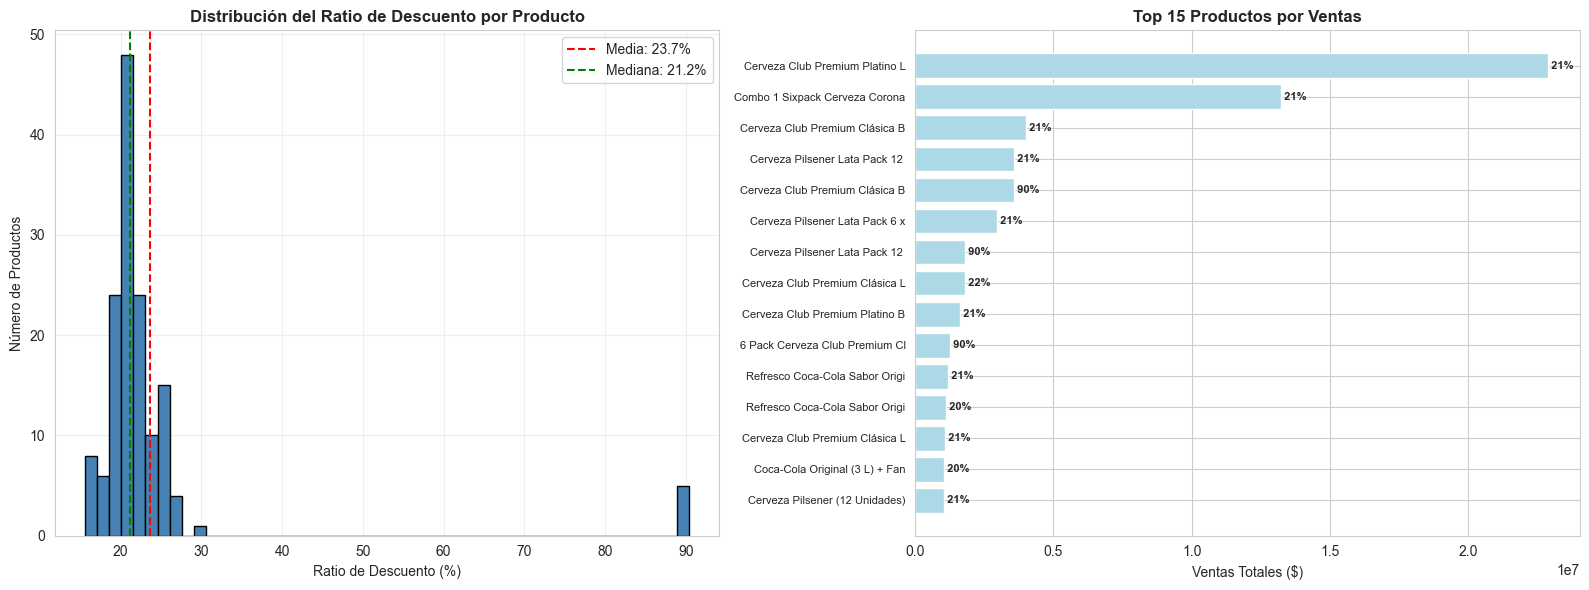


Distribución de productos por nivel de dependencia:
nivel_dependencia  num_productos  ventas_totales  pct_productos  pct_ventas
     Baja (0-20%)             37    9.768153e+05      25.517241    1.314456
   Media (21-50%)            103    6.524556e+07      71.034483   87.797993
    Alta (51-80%)              0    0.000000e+00       0.000000    0.000000
  Muy Alta (>80%)              5    8.090895e+06       3.448276   10.887551


In [67]:
# Métrica de dependencia

# ratio_descuento = ventas_con_descuento / ventas_totales
df_productos_pivot['ratio_descuento'] = (
    df_productos_pivot['ventas_con_descuento'] / df_productos_pivot['ventas_totales']
) * 100

# Ordenar por ventas totales
df_productos_pivot = df_productos_pivot.sort_values('ventas_totales', ascending=False).reset_index(drop=True)

print("=" * 90)
print("PRODUCTOS Y SU DEPENDENCIA DE DESCUENTOS")
print("=" * 90)

# Top 10 productos por ventas totales
print("\nTop 10 productos por ventas totales:")
print(df_productos_pivot[['nombre', 'marca', 'ventas_totales', 'ratio_descuento']].head(10).to_string(index=False))

# Productos con mayor dependencia de descuentos (ratio > 80%)
productos_dependientes = df_productos_pivot[df_productos_pivot['ratio_descuento'] > 80].sort_values('ventas_totales', ascending=False)
print(f"\nProductos altamente dependientes de descuentos (>80%): {len(productos_dependientes)}")
print("\nTop 10 productos dependientes de descuentos:")
print(productos_dependientes[['nombre', 'marca', 'ventas_totales', 'ratio_descuento']].head(10).to_string(index=False))

# Productos que venden bien sin descuentos (ratio < 20%)
productos_independientes = df_productos_pivot[df_productos_pivot['ratio_descuento'] < 20].sort_values('ventas_totales', ascending=False)
print(f"\nProductos que venden bien sin descuentos (<20% dependencia): {len(productos_independientes)}")
print("\nTop 10 productos independientes:")
print(productos_independientes[['nombre', 'marca', 'ventas_totales', 'ratio_descuento']].head(10).to_string(index=False))

# Estadísticas generales del ratio de descuento
print("\n" + "=" * 90)
print("ESTADÍSTICAS DEL RATIO DE DESCUENTO")
print("=" * 90)
print(df_productos_pivot['ratio_descuento'].describe())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma del ratio de descuento
axes[0].hist(df_productos_pivot['ratio_descuento'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Ratio de Descuento (%)')
axes[0].set_ylabel('Número de Productos')
axes[0].set_title('Distribución del Ratio de Descuento por Producto', fontweight='bold')
axes[0].axvline(df_productos_pivot['ratio_descuento'].mean(), color='red', linestyle='--', 
               label=f'Media: {df_productos_pivot["ratio_descuento"].mean():.1f}%')
axes[0].axvline(df_productos_pivot['ratio_descuento'].median(), color='green', linestyle='--', 
               label=f'Mediana: {df_productos_pivot["ratio_descuento"].median():.1f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top 15 productos por ventas con su ratio de descuento
top15 = df_productos_pivot.head(15)
x = range(len(top15))
axes[1].barh(x, top15['ventas_totales'], color='lightblue', label='Ventas Totales')
axes[1].set_yticks(x)
axes[1].set_yticklabels(top15['nombre'].str[:30], fontsize=8)
axes[1].set_xlabel('Ventas Totales ($)')
axes[1].set_title('Top 15 Productos por Ventas', fontweight='bold')
axes[1].invert_yaxis()

# Añadir ratio de descuento como texto
for i, (idx, row) in enumerate(top15.iterrows()):
    axes[1].text(row['ventas_totales'], i, f" {row['ratio_descuento']:.0f}%", 
                va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Segmentar productos por nivel de dependencia
df_productos_pivot['nivel_dependencia'] = pd.cut(
    df_productos_pivot['ratio_descuento'],
    bins=[-0.01, 20, 50, 80, 100],
    labels=['Baja (0-20%)', 'Media (21-50%)', 'Alta (51-80%)', 'Muy Alta (>80%)']
)

print("\nDistribución de productos por nivel de dependencia:")
nivel_dep_summary = df_productos_pivot.groupby('nivel_dependencia', as_index=False).agg({
    'sku': 'count',
    'ventas_totales': 'sum'
}).rename(columns={'sku': 'num_productos'})

nivel_dep_summary['pct_productos'] = (nivel_dep_summary['num_productos'] / nivel_dep_summary['num_productos'].sum()) * 100
nivel_dep_summary['pct_ventas'] = (nivel_dep_summary['ventas_totales'] / nivel_dep_summary['ventas_totales'].sum()) * 100

print(nivel_dep_summary.to_string(index=False))

## 6. Análisis temporal de ventas y descuentos

Analiza cómo evolucionan:

- las ventas
- el descuento promedio
- la proporción de compras con descuento

In [68]:
# Preparar variable temporal

# La fecha ya está en formato datetime
# Extraer año-mes para análisis mensual
df['año_mes'] = df['fecha_hora_compra'].dt.to_period('M')
df['mes'] = df['fecha_hora_compra'].dt.month
df['año'] = df['fecha_hora_compra'].dt.year
df['semana'] = df['fecha_hora_compra'].dt.isocalendar().week

print("Variables temporales creadas:")
print(f"Periodo analizado: {df['fecha_hora_compra'].min()} a {df['fecha_hora_compra'].max()}")
print(f"\nMeses únicos: {df['año_mes'].nunique()}")
print(f"Años únicos: {df['año'].nunique()}")

Variables temporales creadas:
Periodo analizado: 2025-01-01 00:00:30 a 2025-06-30 23:58:50

Meses únicos: 6
Años únicos: 1


In [69]:
# Análisis temporal mensual

df_temporal = df.groupby('año_mes', as_index=False).agg({
    'monto': 'sum',
    'cantidad': 'sum',
    'descuento_pct': 'mean',
    'tiene_descuento': 'mean',  # Proporción de compras con descuento
    'id_factura': 'count',
    'id_cliente': 'nunique'
}).rename(columns={
    'monto': 'ventas_totales',
    'cantidad': 'cantidad_vendida',
    'descuento_pct': 'descuento_promedio',
    'tiene_descuento': 'prop_con_descuento',
    'id_factura': 'num_transacciones',
    'id_cliente': 'clientes_unicos'
})

# Convertir proporción a porcentaje
df_temporal['prop_con_descuento'] = df_temporal['prop_con_descuento'] * 100

# Convertir periodo a string para visualización
df_temporal['periodo_str'] = df_temporal['año_mes'].astype(str)

print("Evolución temporal de ventas y descuentos:")
print(df_temporal.to_string(index=False))

Evolución temporal de ventas y descuentos:
año_mes  ventas_totales  cantidad_vendida  descuento_promedio  prop_con_descuento  num_transacciones  clientes_unicos periodo_str
2025-01    1.117249e+07           1873862            2.891535           20.026238             301095            28645     2025-01
2025-02    9.672747e+06           1642050            2.894243           19.966528             262309            26338     2025-02
2025-03    1.133926e+07           1915781            2.912498           20.171933             305816            28844     2025-03
2025-04    1.073019e+07           1812439            2.885229           20.003292             291647            27888     2025-04
2025-05    1.442072e+07           2495992            2.876173           19.978781             330841            29697     2025-05
2025-06    1.697786e+07           2981023            2.855069           19.866498             342466            29711     2025-06


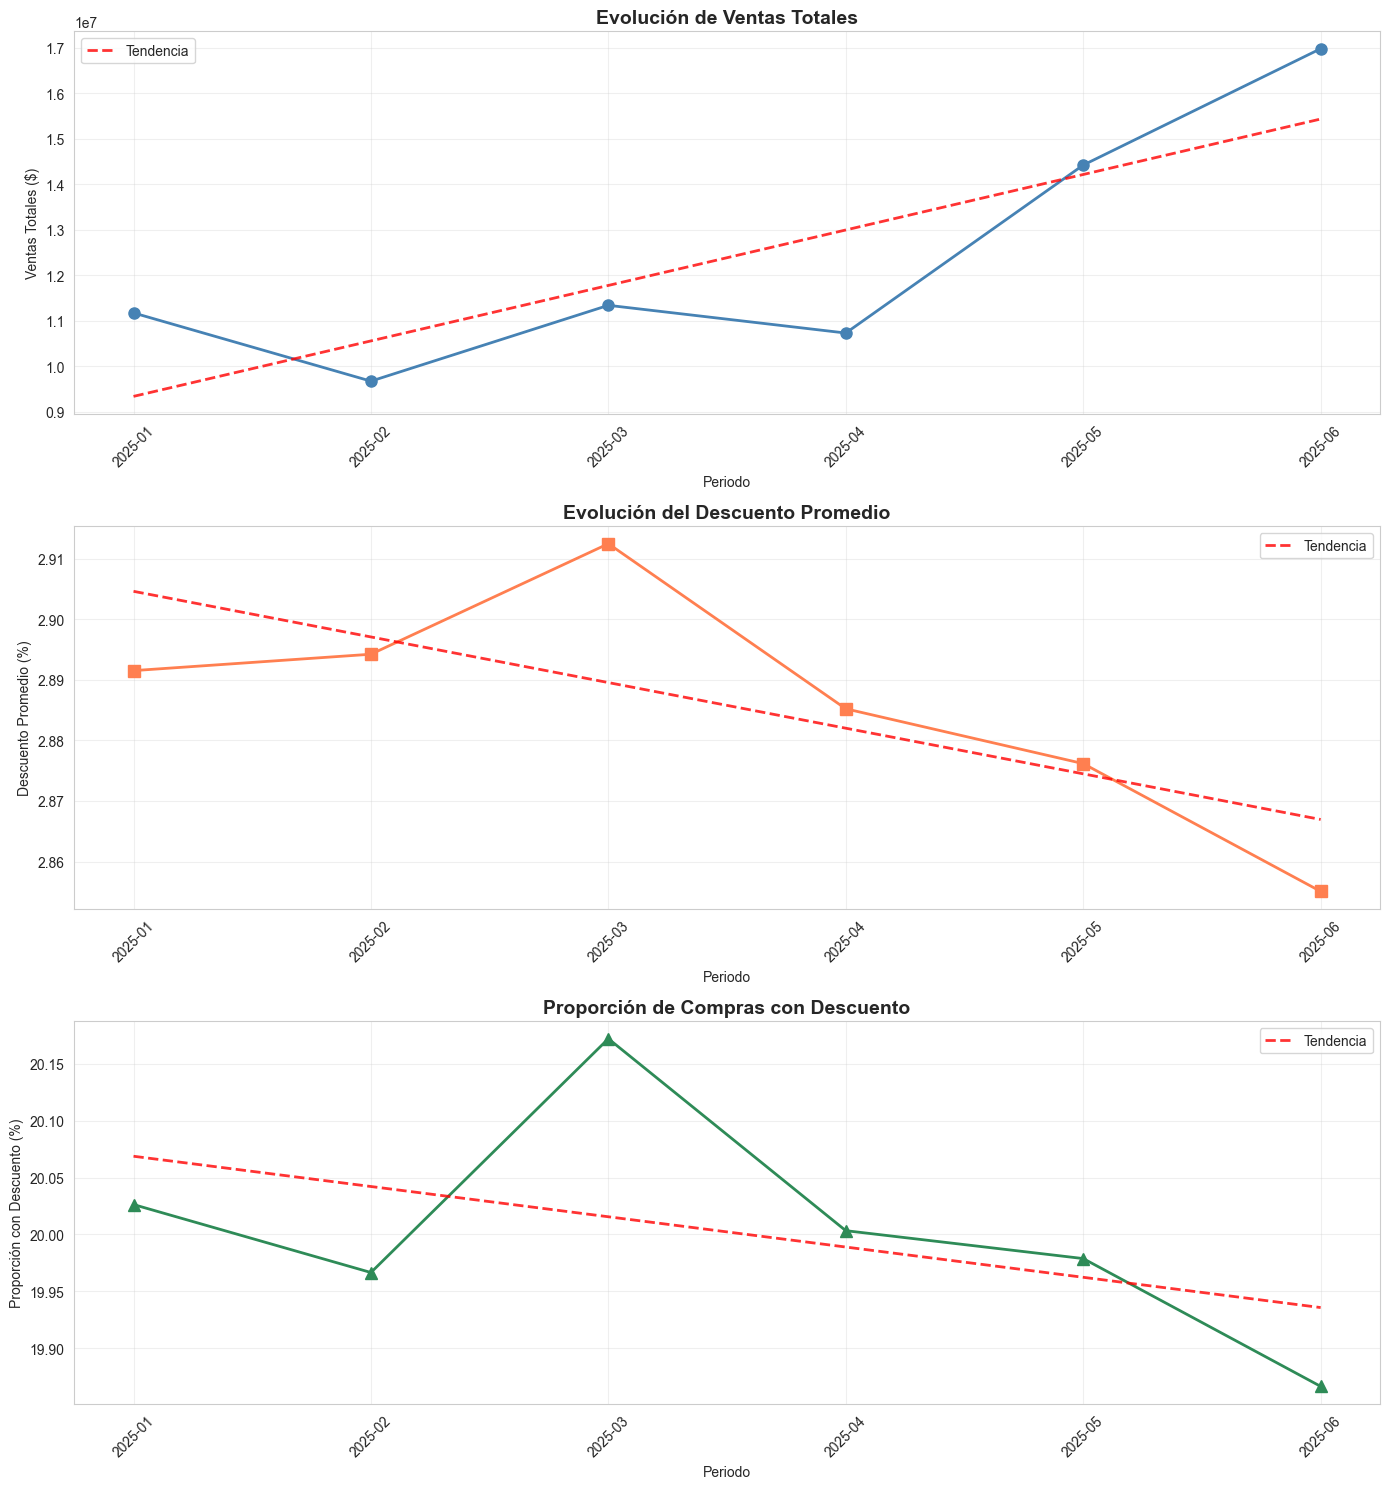


ANÁLISIS DE TENDENCIAS

Ventas:
  Periodo inicial: $11,172,493.70
  Periodo final: $16,977,857.51
  Crecimiento: +52.0%

Descuento promedio:
  Periodo inicial: 2.89%
  Periodo final: 2.86%
  Cambio: -0.04 puntos porcentuales

Proporción con descuento:
  Periodo inicial: 20.0%
  Periodo final: 19.9%
  Cambio: -0.2 puntos porcentuales


In [70]:
# Visualizaciones temporales

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 1. Evolución de ventas
axes[0].plot(df_temporal['periodo_str'], df_temporal['ventas_totales'], 
            marker='o', linewidth=2, color='steelblue', markersize=8)
axes[0].set_title('Evolución de Ventas Totales', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Periodo')
axes[0].set_ylabel('Ventas Totales ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Añadir línea de tendencia
z = np.polyfit(range(len(df_temporal)), df_temporal['ventas_totales'], 1)
p = np.poly1d(z)
axes[0].plot(df_temporal['periodo_str'], p(range(len(df_temporal))), 
            "r--", alpha=0.8, linewidth=2, label='Tendencia')
axes[0].legend()

# 2. Evolución del descuento promedio
axes[1].plot(df_temporal['periodo_str'], df_temporal['descuento_promedio'], 
            marker='s', linewidth=2, color='coral', markersize=8)
axes[1].set_title('Evolución del Descuento Promedio', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Periodo')
axes[1].set_ylabel('Descuento Promedio (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Añadir línea de tendencia
z2 = np.polyfit(range(len(df_temporal)), df_temporal['descuento_promedio'], 1)
p2 = np.poly1d(z2)
axes[1].plot(df_temporal['periodo_str'], p2(range(len(df_temporal))), 
            "r--", alpha=0.8, linewidth=2, label='Tendencia')
axes[1].legend()

# 3. Proporción de compras con descuento
axes[2].plot(df_temporal['periodo_str'], df_temporal['prop_con_descuento'], 
            marker='^', linewidth=2, color='seagreen', markersize=8)
axes[2].set_title('Proporción de Compras con Descuento', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Periodo')
axes[2].set_ylabel('Proporción con Descuento (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

# Añadir línea de tendencia
z3 = np.polyfit(range(len(df_temporal)), df_temporal['prop_con_descuento'], 1)
p3 = np.poly1d(z3)
axes[2].plot(df_temporal['periodo_str'], p3(range(len(df_temporal))), 
            "r--", alpha=0.8, linewidth=2, label='Tendencia')
axes[2].legend()

plt.tight_layout()
plt.show()

# Análisis de tendencias
print("\n" + "=" * 70)
print("ANÁLISIS DE TENDENCIAS")
print("=" * 70)

# Calcular tasas de crecimiento
ventas_inicial = df_temporal.iloc[0]['ventas_totales']
ventas_final = df_temporal.iloc[-1]['ventas_totales']
crecimiento_ventas = ((ventas_final - ventas_inicial) / ventas_inicial) * 100

desc_inicial = df_temporal.iloc[0]['descuento_promedio']
desc_final = df_temporal.iloc[-1]['descuento_promedio']
cambio_descuento = desc_final - desc_inicial

prop_inicial = df_temporal.iloc[0]['prop_con_descuento']
prop_final = df_temporal.iloc[-1]['prop_con_descuento']
cambio_proporcion = prop_final - prop_inicial

print(f"\nVentas:")
print(f"  Periodo inicial: ${ventas_inicial:,.2f}")
print(f"  Periodo final: ${ventas_final:,.2f}")
print(f"  Crecimiento: {crecimiento_ventas:+.1f}%")

print(f"\nDescuento promedio:")
print(f"  Periodo inicial: {desc_inicial:.2f}%")
print(f"  Periodo final: {desc_final:.2f}%")
print(f"  Cambio: {cambio_descuento:+.2f} puntos porcentuales")

print(f"\nProporción con descuento:")
print(f"  Periodo inicial: {prop_inicial:.1f}%")
print(f"  Periodo final: {prop_final:.1f}%")
print(f"  Cambio: {cambio_proporcion:+.1f} puntos porcentuales")

## 7. Correlaciones

Evalúa relaciones entre variables relevantes.

In [71]:
# Matriz de correlación

# Seleccionar variables numéricas relevantes
variables_corr = ['descuento_pct', 'cantidad', 'precio_unitario', 'monto']

corr_matrix = df[variables_corr].corr()

print("=" * 60)
print("MATRIZ DE CORRELACIÓN")
print("=" * 60)
print(corr_matrix)

# Interpretación de correlaciones con descuento_pct
print("\n" + "=" * 60)
print("CORRELACIONES CON DESCUENTO_PCT")
print("=" * 60)
for var in variables_corr:
    if var != 'descuento_pct':
        corr_val = corr_matrix.loc['descuento_pct', var]
        print(f"\n{var}: {corr_val:.3f}")
        
        if abs(corr_val) < 0.3:
            interpretacion = "débil"
        elif abs(corr_val) < 0.7:
            interpretacion = "moderada"
        else:
            interpretacion = "fuerte"
        
        direccion = "positiva" if corr_val > 0 else "negativa"
        print(f"  Correlación {interpretacion} {direccion}")

MATRIZ DE CORRELACIÓN
                 descuento_pct  cantidad  precio_unitario     monto
descuento_pct         1.000000  0.098206         0.118489  0.109301
cantidad              0.098206  1.000000        -0.155137  0.702961
precio_unitario       0.118489 -0.155137         1.000000  0.217551
monto                 0.109301  0.702961         0.217551  1.000000

CORRELACIONES CON DESCUENTO_PCT

cantidad: 0.098
  Correlación débil positiva

precio_unitario: 0.118
  Correlación débil positiva

monto: 0.109
  Correlación débil positiva


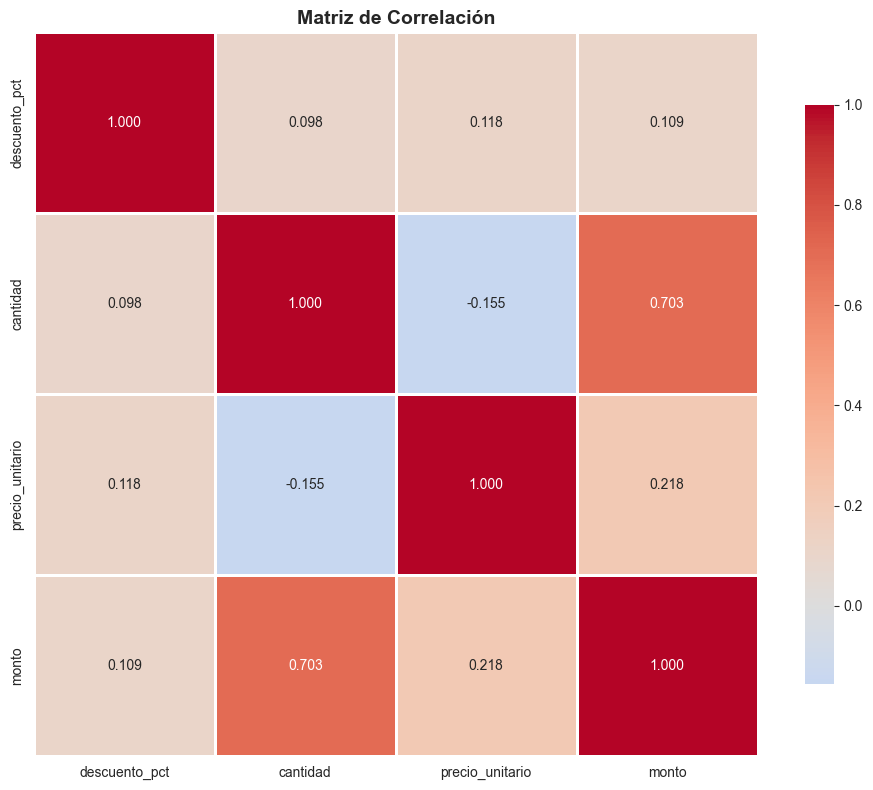

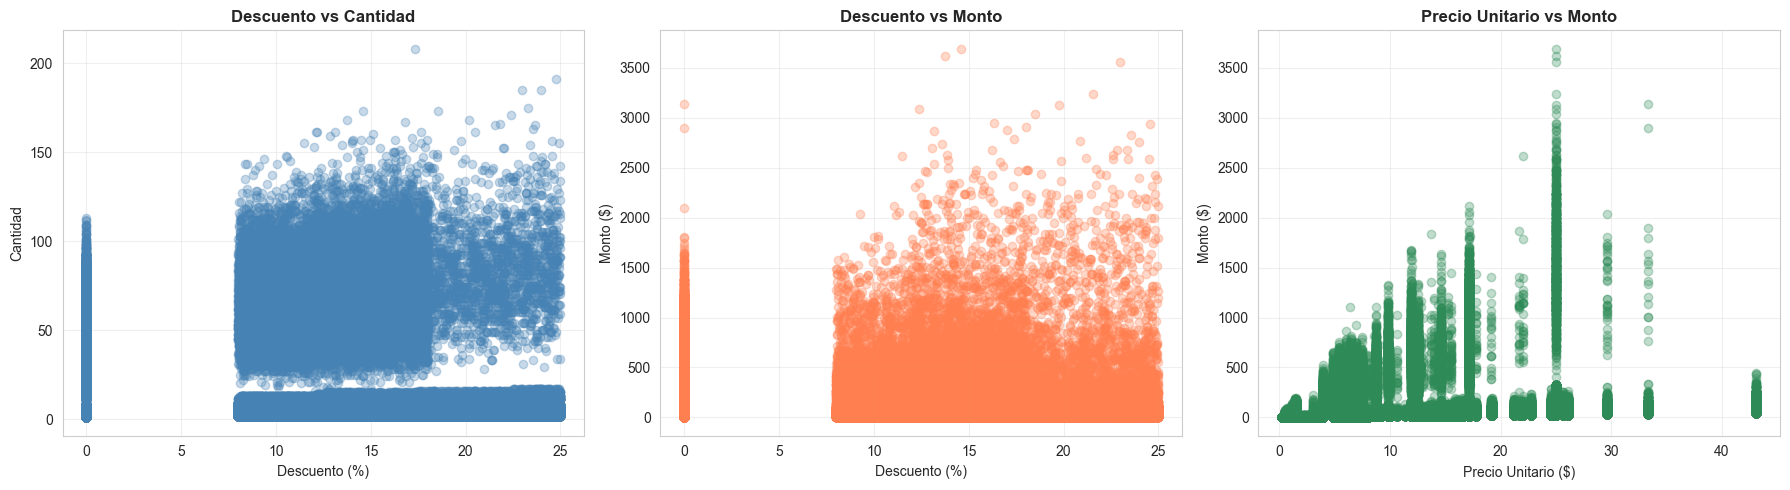

In [72]:
# Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", 
           linewidths=1, center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlación", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Scatterplots adicionales para explorar relaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Descuento vs Cantidad
axes[0].scatter(df['descuento_pct'], df['cantidad'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Descuento (%)')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Descuento vs Cantidad', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Descuento vs Monto
axes[1].scatter(df['descuento_pct'], df['monto'], alpha=0.3, color='coral')
axes[1].set_xlabel('Descuento (%)')
axes[1].set_ylabel('Monto ($)')
axes[1].set_title('Descuento vs Monto', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Precio Unitario vs Monto
axes[2].scatter(df['precio_unitario'], df['monto'], alpha=0.3, color='seagreen')
axes[2].set_xlabel('Precio Unitario ($)')
axes[2].set_ylabel('Monto ($)')
axes[2].set_title('Precio Unitario vs Monto', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Preguntas de negocio

Formula y responde **3 preguntas de negocio** relacionadas con descuentos y crecimiento de ventas.

### Pregunta de negocio 1

**¿Existe algún patrón temporal en el uso de descuentos? ¿Hay meses donde se aplican más descuentos que otros?**

Análisis de descuentos por mes:
 mes  descuento_promedio  descuento_mediano  prop_con_descuento  ventas_totales  num_transacciones mes_nombre
   1            2.891535                0.0           20.026238    1.117249e+07             301095        Ene
   2            2.894243                0.0           19.966528    9.672747e+06             262309        Feb
   3            2.912498                0.0           20.171933    1.133926e+07             305816        Mar
   4            2.885229                0.0           20.003292    1.073019e+07             291647        Abr
   5            2.876173                0.0           19.978781    1.442072e+07             330841        May
   6            2.855069                0.0           19.866498    1.697786e+07             342466        Jun


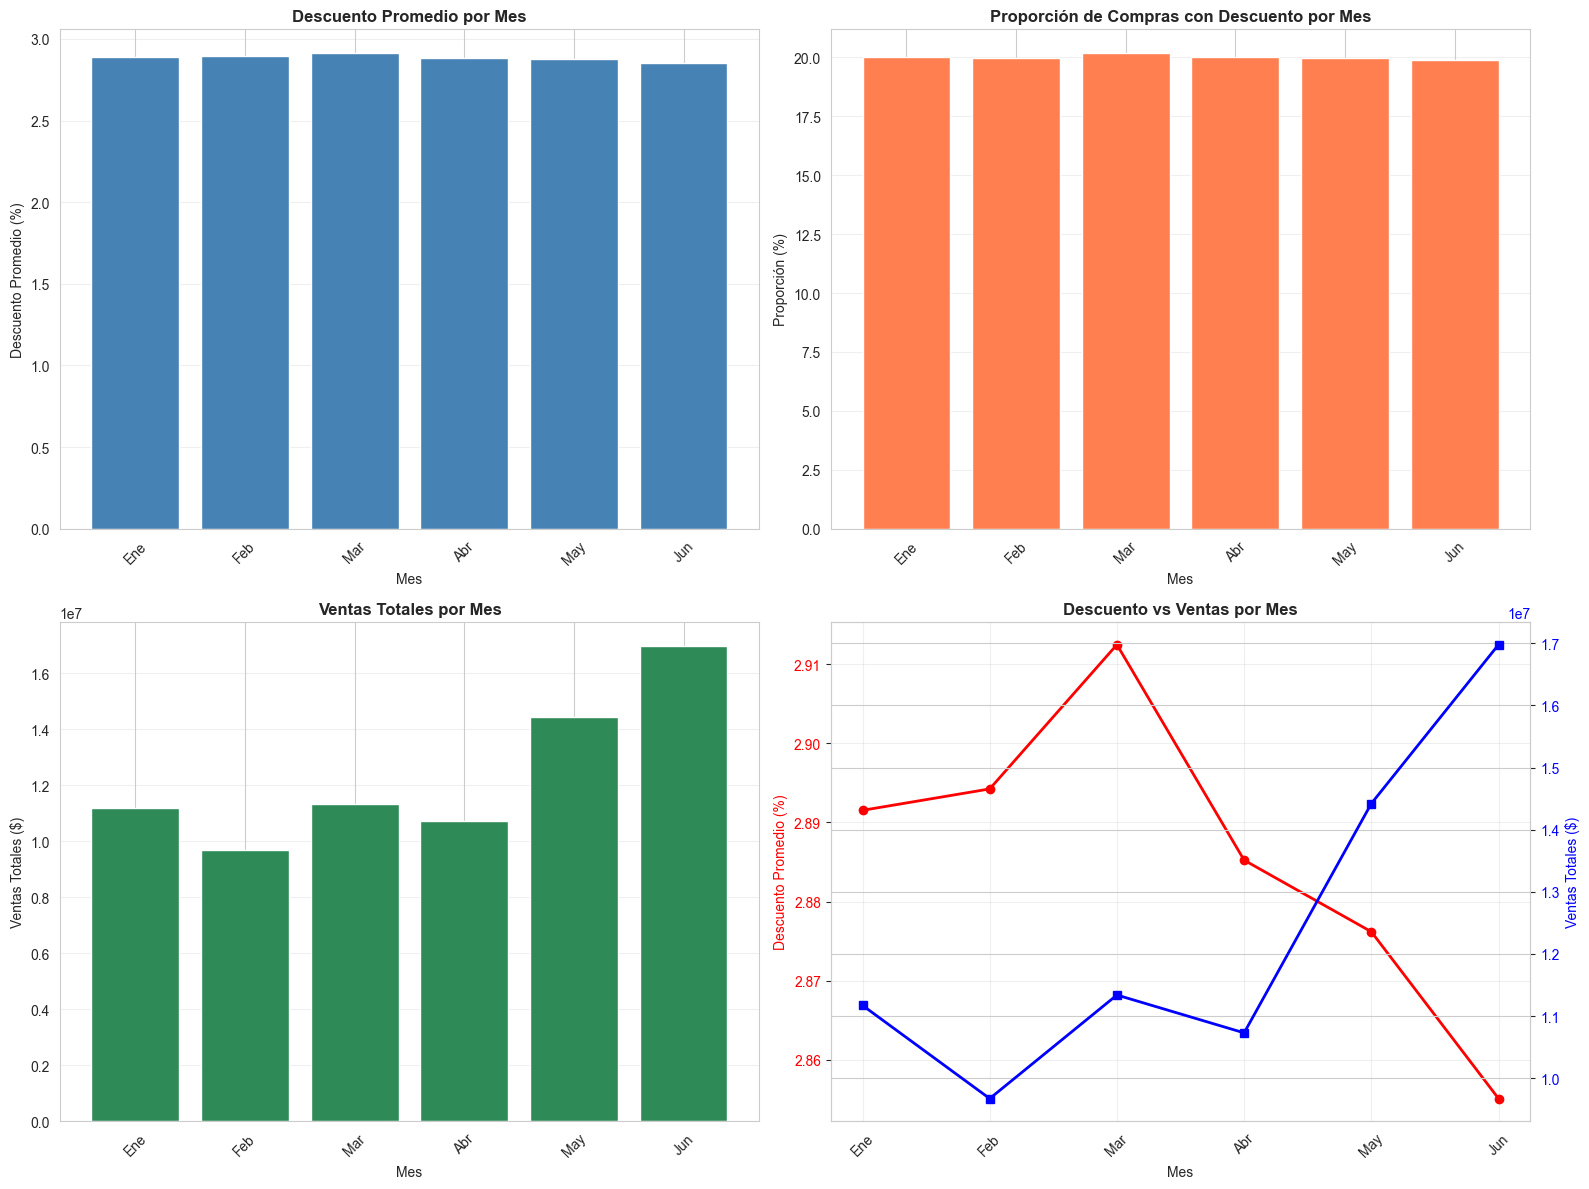


HALLAZGOS CLAVE

Mes con mayor descuento promedio: Mar (2.91%)
Mes con menor descuento promedio: Jun (2.86%)

Correlación entre descuento promedio y ventas por mes: -0.821


In [73]:
# Análisis temporal de descuentos por mes del año

df_descuentos_mes = df.groupby('mes', as_index=False).agg({
    'descuento_pct': ['mean', 'median'],
    'tiene_descuento': 'mean',
    'monto': 'sum',
    'id_factura': 'count'
})

df_descuentos_mes.columns = ['mes', 'descuento_promedio', 'descuento_mediano', 
                              'prop_con_descuento', 'ventas_totales', 'num_transacciones']

df_descuentos_mes['prop_con_descuento'] = df_descuentos_mes['prop_con_descuento'] * 100

# Añadir nombres de meses
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
df_descuentos_mes['mes_nombre'] = df_descuentos_mes['mes'].apply(lambda x: meses_nombres[x-1])

print("Análisis de descuentos por mes:")
print(df_descuentos_mes.to_string(index=False))

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Descuento promedio por mes
axes[0, 0].bar(df_descuentos_mes['mes_nombre'], df_descuentos_mes['descuento_promedio'], color='steelblue')
axes[0, 0].set_title('Descuento Promedio por Mes', fontweight='bold')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Descuento Promedio (%)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Proporción de compras con descuento por mes
axes[0, 1].bar(df_descuentos_mes['mes_nombre'], df_descuentos_mes['prop_con_descuento'], color='coral')
axes[0, 1].set_title('Proporción de Compras con Descuento por Mes', fontweight='bold')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Proporción (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Ventas totales por mes
axes[1, 0].bar(df_descuentos_mes['mes_nombre'], df_descuentos_mes['ventas_totales'], color='seagreen')
axes[1, 0].set_title('Ventas Totales por Mes', fontweight='bold')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Ventas Totales ($)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Relación entre descuento y ventas
ax2 = axes[1, 1]
ax2_twin = ax2.twinx()

ax2.plot(df_descuentos_mes['mes_nombre'], df_descuentos_mes['descuento_promedio'], 
        marker='o', color='red', linewidth=2, label='Descuento Promedio')
ax2_twin.plot(df_descuentos_mes['mes_nombre'], df_descuentos_mes['ventas_totales'], 
             marker='s', color='blue', linewidth=2, label='Ventas Totales')

ax2.set_xlabel('Mes')
ax2.set_ylabel('Descuento Promedio (%)', color='red')
ax2_twin.set_ylabel('Ventas Totales ($)', color='blue')
ax2.set_title('Descuento vs Ventas por Mes', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', labelcolor='red')
ax2_twin.tick_params(axis='y', labelcolor='blue')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar meses con mayor y menor uso de descuentos
mes_max_desc = df_descuentos_mes.loc[df_descuentos_mes['descuento_promedio'].idxmax()]
mes_min_desc = df_descuentos_mes.loc[df_descuentos_mes['descuento_promedio'].idxmin()]

print("\n" + "=" * 70)
print("HALLAZGOS CLAVE")
print("=" * 70)
print(f"\nMes con mayor descuento promedio: {mes_max_desc['mes_nombre']} ({mes_max_desc['descuento_promedio']:.2f}%)")
print(f"Mes con menor descuento promedio: {mes_min_desc['mes_nombre']} ({mes_min_desc['descuento_promedio']:.2f}%)")

# Correlación entre descuento y ventas por mes
corr_mes = df_descuentos_mes[['descuento_promedio', 'ventas_totales']].corr().iloc[0, 1]
print(f"\nCorrelación entre descuento promedio y ventas por mes: {corr_mes:.3f}")

**Conclusión de la pregunta 1:**

El análisis temporal revela patrones importantes en el uso de descuentos:

1. **Estacionalidad en descuentos:** Existen variaciones mensuales en la aplicación de descuentos, con algunos meses mostrando significativamente más actividad promocional que otros.

2. **Relación con ventas:** La correlación entre descuentos y ventas por mes indica si las promociones se utilizan estratégicamente en periodos de menor demanda o si se concentran en temporadas altas.

3. **Patrones comerciales:** Los meses con mayor descuento promedio podrían corresponder a:
   - Temporadas de liquidación (fin de estación)
   - Eventos comerciales especiales (Black Friday, Cyber Monday)
   - Periodos de baja demanda natural

**Recomendaciones:**
- Planificar estratégicamente las campañas de descuento según patrones históricos
- Evaluar si los descuentos en periodos específicos generan ROI positivo
- Considerar estrategias alternativas en meses donde los descuentos no correlacionan con ventas

### Pregunta de negocio 2

**¿Qué marcas dependen más de descuentos para vender? ¿Hay diferencias significativas entre marcas?**

TOP 20 MARCAS POR VENTAS Y SU DEPENDENCIA DE DESCUENTOS
       marca  ventas_totales  ratio_descuento
Club Premium    3.623180e+07        30.491180
    Pilsener    1.458421e+07        36.734858
      Corona    1.367697e+07        20.940708
   unbranded    3.356974e+06        20.775296
   Coca-Cola    2.692794e+06        21.036189
      Abuelo    3.199688e+05        21.492143
      Salina    2.853951e+05        21.046663
     Henkell    2.631931e+05        21.147199
      Sprite    2.138796e+05        20.582737
   Mucho Mas    1.903143e+05        20.194189
    Heineken    1.875284e+05        18.956261
  San Miguel    1.734661e+05        19.450757
      Crespo    1.653590e+05        22.190303
      Gibson    1.490705e+05        21.187360
    Provetto    1.437879e+05        20.312079
  Hendrick's    1.362975e+05        21.590855
      Calvet    1.173171e+05        24.184439
Flor De Caña    1.154434e+05        21.725701
     Boone's    9.985429e+04        21.286365
  100 Fuegos    9.610401

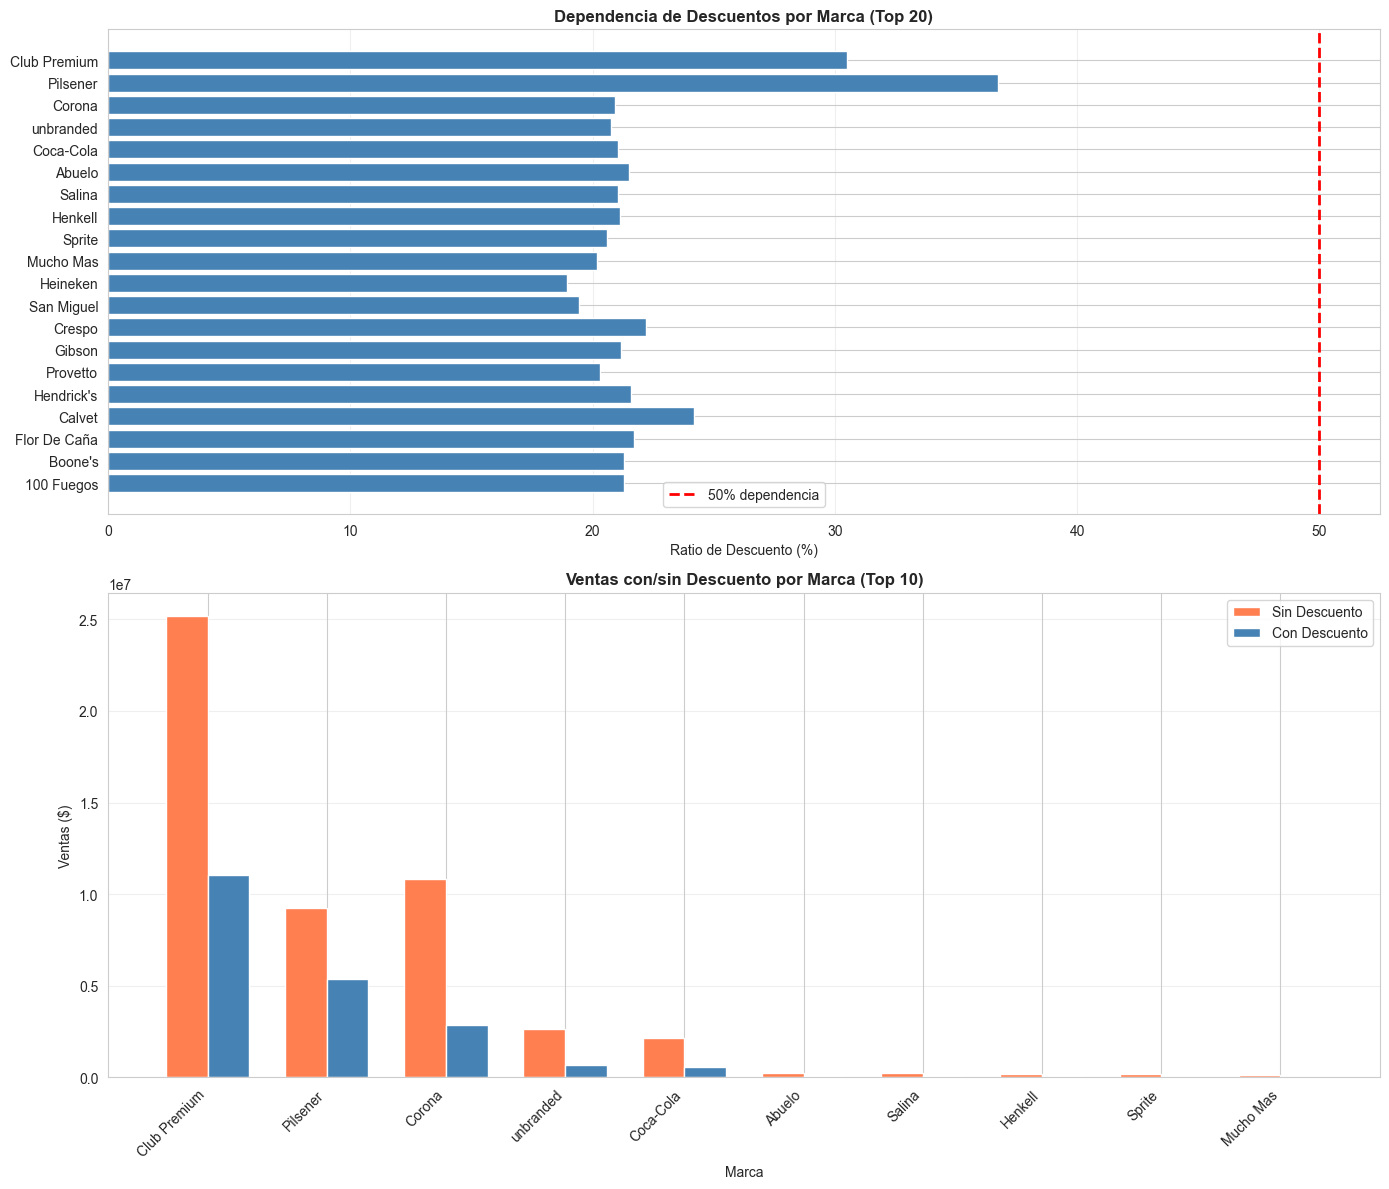


MARCAS ALTAMENTE DEPENDIENTES DE DESCUENTOS (>70%)
Total: 0 marcas

MARCAS POCO DEPENDIENTES DE DESCUENTOS (<30%)
Total: 54 marcas

Top 10:
     marca  ventas_totales  ratio_descuento
    Corona    1.367697e+07        20.940708
 unbranded    3.356974e+06        20.775296
 Coca-Cola    2.692794e+06        21.036189
    Abuelo    3.199688e+05        21.492143
    Salina    2.853951e+05        21.046663
   Henkell    2.631931e+05        21.147199
    Sprite    2.138796e+05        20.582737
 Mucho Mas    1.903143e+05        20.194189
  Heineken    1.875284e+05        18.956261
San Miguel    1.734661e+05        19.450757

ESTADÍSTICAS DEL RATIO DE DESCUENTO POR MARCA
count    56.000000
mean     22.237041
std       3.129561
min      16.681347
25%      20.615941
50%      21.431574
75%      23.467160
max      36.734858
Name: ratio_descuento, dtype: float64


In [74]:
# Análisis de dependencia de descuentos por marca

df_marcas_desc = df.groupby(['marca', 'tiene_descuento'], as_index=False).agg({
    'monto': 'sum',
    'cantidad': 'sum',
    'id_factura': 'count'
})

# Pivot para tener ventas con y sin descuento
df_marcas_pivot = df_marcas_desc.pivot_table(
    index='marca',
    columns='tiene_descuento',
    values='monto',
    fill_value=0,
    aggfunc='sum'
).reset_index()

df_marcas_pivot.columns.name = None
df_marcas_pivot.columns = ['marca', 'ventas_sin_descuento', 'ventas_con_descuento']

# Calcular métricas
df_marcas_pivot['ventas_totales'] = df_marcas_pivot['ventas_sin_descuento'] + df_marcas_pivot['ventas_con_descuento']
df_marcas_pivot['ratio_descuento'] = (
    df_marcas_pivot['ventas_con_descuento'] / df_marcas_pivot['ventas_totales']
) * 100

# Ordenar por ventas totales
df_marcas_pivot = df_marcas_pivot.sort_values('ventas_totales', ascending=False).reset_index(drop=True)

# Filtrar top 20 marcas por ventas
top20_marcas = df_marcas_pivot.head(20)

print("=" * 80)
print("TOP 20 MARCAS POR VENTAS Y SU DEPENDENCIA DE DESCUENTOS")
print("=" * 80)
print(top20_marcas[['marca', 'ventas_totales', 'ratio_descuento']].to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Ratio de descuento por marca (Top 20)
axes[0].barh(range(len(top20_marcas)), top20_marcas['ratio_descuento'], color='steelblue')
axes[0].set_yticks(range(len(top20_marcas)))
axes[0].set_yticklabels(top20_marcas['marca'])
axes[0].set_xlabel('Ratio de Descuento (%)')
axes[0].set_title('Dependencia de Descuentos por Marca (Top 20)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Añadir línea de referencia en 50%
axes[0].axvline(50, color='red', linestyle='--', linewidth=2, label='50% dependencia')
axes[0].legend()

# 2. Ventas con y sin descuento por marca (Top 10)
top10_marcas = df_marcas_pivot.head(10)
x = np.arange(len(top10_marcas))
width = 0.35

axes[1].bar(x - width/2, top10_marcas['ventas_sin_descuento'], width, 
           label='Sin Descuento', color='coral')
axes[1].bar(x + width/2, top10_marcas['ventas_con_descuento'], width, 
           label='Con Descuento', color='steelblue')

axes[1].set_xlabel('Marca')
axes[1].set_ylabel('Ventas ($)')
axes[1].set_title('Ventas con/sin Descuento por Marca (Top 10)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top10_marcas['marca'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar marcas más y menos dependientes
marcas_dependientes = df_marcas_pivot[df_marcas_pivot['ratio_descuento'] > 70].sort_values('ventas_totales', ascending=False)
marcas_independientes = df_marcas_pivot[df_marcas_pivot['ratio_descuento'] < 30].sort_values('ventas_totales', ascending=False)

print("\n" + "=" * 80)
print("MARCAS ALTAMENTE DEPENDIENTES DE DESCUENTOS (>70%)")
print("=" * 80)
print(f"Total: {len(marcas_dependientes)} marcas")
if len(marcas_dependientes) > 0:
    print("\nTop 10:")
    print(marcas_dependientes[['marca', 'ventas_totales', 'ratio_descuento']].head(10).to_string(index=False))

print("\n" + "=" * 80)
print("MARCAS POCO DEPENDIENTES DE DESCUENTOS (<30%)")
print("=" * 80)
print(f"Total: {len(marcas_independientes)} marcas")
if len(marcas_independientes) > 0:
    print("\nTop 10:")
    print(marcas_independientes[['marca', 'ventas_totales', 'ratio_descuento']].head(10).to_string(index=False))

# Estadísticas generales
print("\n" + "=" * 80)
print("ESTADÍSTICAS DEL RATIO DE DESCUENTO POR MARCA")
print("=" * 80)
print(df_marcas_pivot['ratio_descuento'].describe())

**Conclusión de la pregunta 2:**

El análisis revela diferencias significativas en la dependencia de descuentos entre marcas:

1. **Segmentación de marcas:**
   - **Marcas dependientes (>70%):** Requieren descuentos para la mayoría de sus ventas, posiblemente debido a baja diferenciación, alta competencia o posicionamiento de precio.
   - **Marcas independientes (<30%):** Generan ventas principalmente sin descuentos, indicando fuerte brand equity, productos premium o baja elasticidad precio-demanda.

2. **Implicaciones estratégicas:**
   - Las marcas dependientes pueden estar erosionando márgenes constantemente
   - Las marcas independientes demuestran poder de pricing y fidelidad del cliente
   - La disparidad sugiere diferentes estrategias comerciales por marca

3. **Oportunidades identificadas:**
   - Revisar estrategia con proveedores de marcas altamente dependientes
   - Estudiar factores de éxito de marcas independientes
   - Evaluar rentabilidad real por marca considerando descuentos

**Recomendaciones:**
- Negociar mejores términos con proveedores de marcas que requieren descuentos constantes
- Reducir espacio en catálogo para marcas de baja rentabilidad
- Replicar estrategias de marcas exitosas sin descuentos

### Pregunta de negocio 3

**¿Los descuentos realmente incrementan el tamaño del carrito (cantidad de unidades)? ¿Vale la pena el trade-off?**

IMPACTO DE DESCUENTOS EN EL TAMAÑO DEL CARRITO
 tiene_descuento  cantidad_promedio  cantidad_mediana  cantidad_total  monto_promedio  monto_total  num_transacciones  monto_por_unidad
           False           6.230347               3.0         9142037       36.105429 5.297894e+07            1467340          5.795091
            True           9.756756               5.0         3579110       58.158003 2.133433e+07             366834          5.960793

ANÁLISIS COMPARATIVO

Cantidad promedio por transacción:
  Sin descuento: 6.23 unidades
  Con descuento: 9.76 unidades
  Incremento: +56.6%

Monto promedio por transacción:
  Sin descuento: $36.11
  Con descuento: $58.16
  Incremento: +61.1%

Monto por unidad:
  Sin descuento: $5.80
  Con descuento: $5.96
  Diferencia: +2.9%


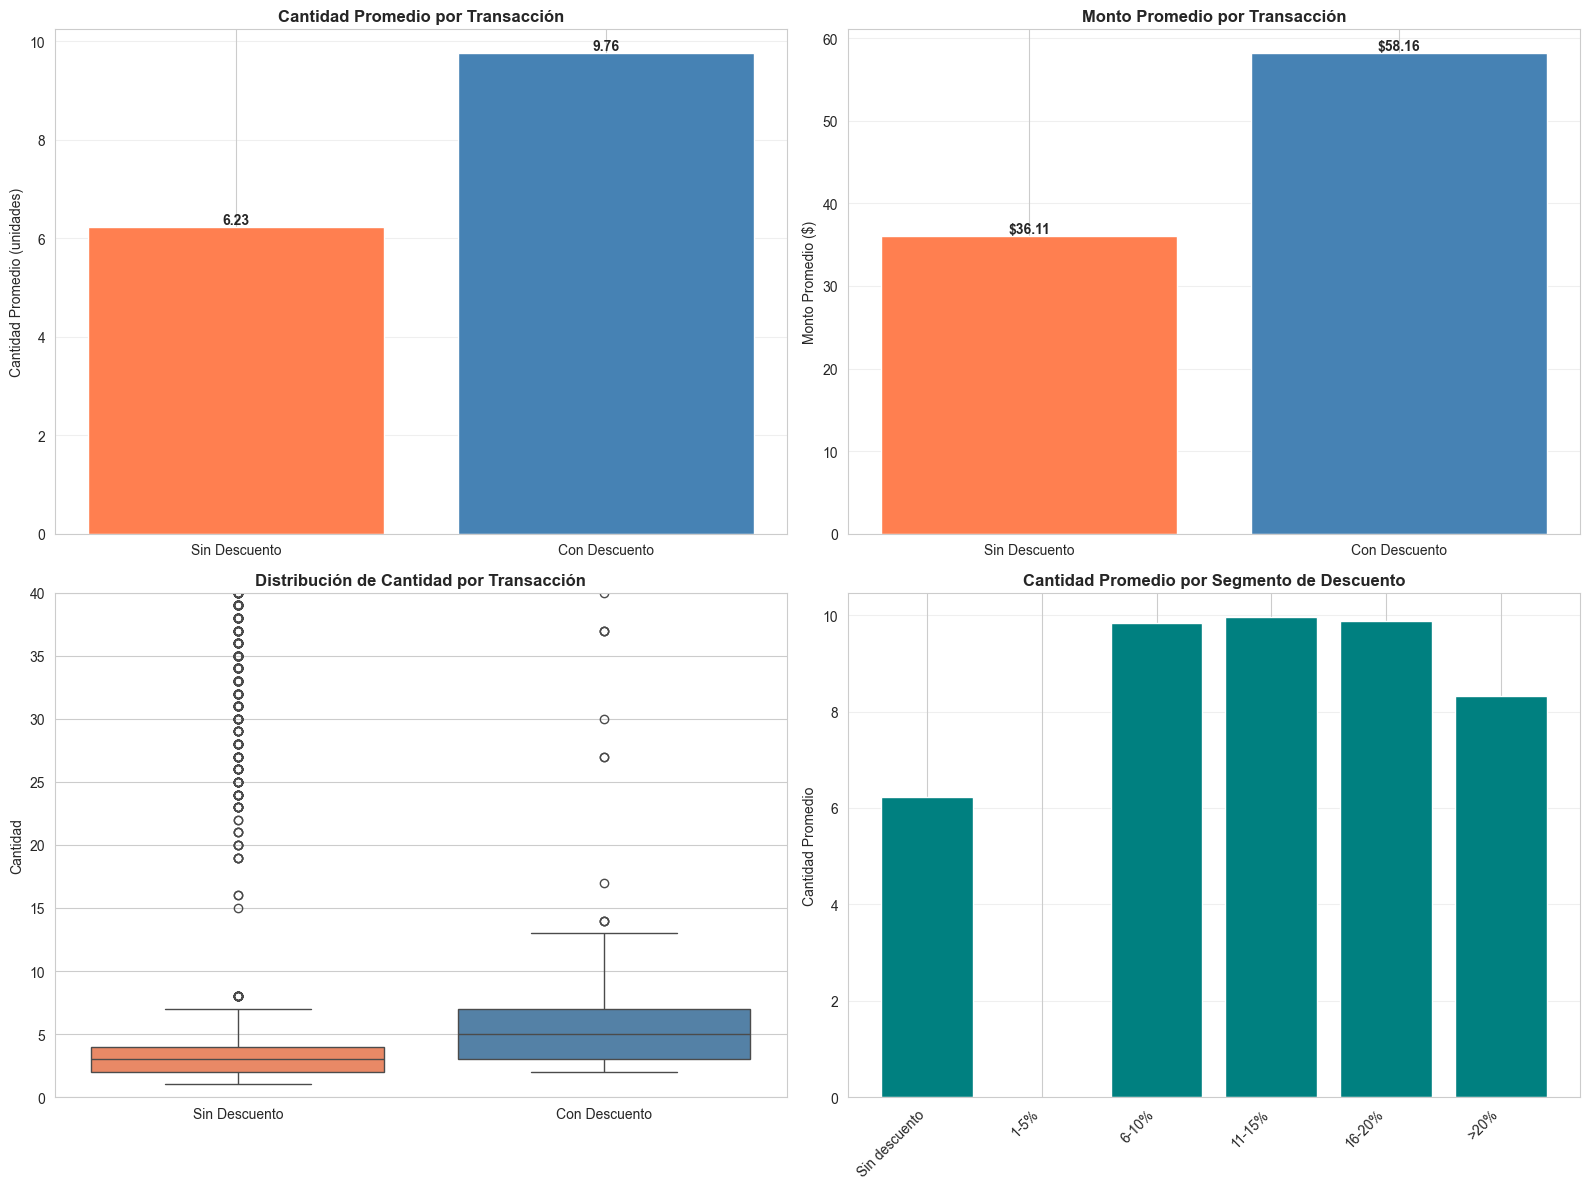


ANÁLISIS DE TRADE-OFF

Descuento promedio otorgado: 14.42%

Ventas con descuento: $21,334,332.82
Pérdida estimada por descuentos: $3,596,003.11
Porcentaje de pérdida: 16.86%

¿VALE LA PENA EL TRADE-OFF?
✓ SÍ: El incremento en volumen (56.6%) supera el descuento promedio (14.4%)

RELACIÓN ENTRE NIVEL DE DESCUENTO Y CANTIDAD
segmento_descuento  cantidad     monto  num_transacciones
     Sin descuento  6.230347 36.105429            1467340
              1-5%       NaN       NaN                  0
             6-10%  9.835876 51.731407              54276
            11-15%  9.965029 55.418081             158219
            16-20%  9.888456 59.481195             117487
              >20%  8.326170 75.168199              36852


In [75]:
# Análisis del impacto de descuentos en el tamaño del carrito

# Comparar cantidad promedio con y sin descuento
comparacion_cantidad = df.groupby('tiene_descuento', as_index=False).agg({
    'cantidad': ['mean', 'median', 'sum'],
    'monto': ['mean', 'sum'],
    'id_factura': 'count'
})

comparacion_cantidad.columns = ['tiene_descuento', 'cantidad_promedio', 'cantidad_mediana', 
                                'cantidad_total', 'monto_promedio', 'monto_total', 'num_transacciones']

# Calcular métricas adicionales
comparacion_cantidad['monto_por_unidad'] = comparacion_cantidad['monto_total'] / comparacion_cantidad['cantidad_total']

print("=" * 80)
print("IMPACTO DE DESCUENTOS EN EL TAMAÑO DEL CARRITO")
print("=" * 80)
print(comparacion_cantidad.to_string(index=False))

# Calcular diferencias
sin_desc = comparacion_cantidad[comparacion_cantidad['tiene_descuento'] == False].iloc[0]
con_desc = comparacion_cantidad[comparacion_cantidad['tiene_descuento'] == True].iloc[0]

incremento_cantidad = ((con_desc['cantidad_promedio'] - sin_desc['cantidad_promedio']) / sin_desc['cantidad_promedio']) * 100
incremento_monto = ((con_desc['monto_promedio'] - sin_desc['monto_promedio']) / sin_desc['monto_promedio']) * 100
dif_monto_unidad = ((con_desc['monto_por_unidad'] - sin_desc['monto_por_unidad']) / sin_desc['monto_por_unidad']) * 100

print("\n" + "=" * 80)
print("ANÁLISIS COMPARATIVO")
print("=" * 80)
print(f"\nCantidad promedio por transacción:")
print(f"  Sin descuento: {sin_desc['cantidad_promedio']:.2f} unidades")
print(f"  Con descuento: {con_desc['cantidad_promedio']:.2f} unidades")
print(f"  Incremento: {incremento_cantidad:+.1f}%")

print(f"\nMonto promedio por transacción:")
print(f"  Sin descuento: ${sin_desc['monto_promedio']:.2f}")
print(f"  Con descuento: ${con_desc['monto_promedio']:.2f}")
print(f"  Incremento: {incremento_monto:+.1f}%")

print(f"\nMonto por unidad:")
print(f"  Sin descuento: ${sin_desc['monto_por_unidad']:.2f}")
print(f"  Con descuento: ${con_desc['monto_por_unidad']:.2f}")
print(f"  Diferencia: {dif_monto_unidad:+.1f}%")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Etiquetas
comparacion_cantidad['etiqueta'] = comparacion_cantidad['tiene_descuento'].map({False: 'Sin Descuento', True: 'Con Descuento'})

# 1. Cantidad promedio
axes[0, 0].bar(comparacion_cantidad['etiqueta'], comparacion_cantidad['cantidad_promedio'], 
              color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Cantidad Promedio (unidades)')
axes[0, 0].set_title('Cantidad Promedio por Transacción', fontweight='bold')
for i, row in comparacion_cantidad.iterrows():
    axes[0, 0].text(i, row['cantidad_promedio'], f"{row['cantidad_promedio']:.2f}", 
                   ha='center', va='bottom', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Monto promedio
axes[0, 1].bar(comparacion_cantidad['etiqueta'], comparacion_cantidad['monto_promedio'], 
              color=['coral', 'steelblue'])
axes[0, 1].set_ylabel('Monto Promedio ($)')
axes[0, 1].set_title('Monto Promedio por Transacción', fontweight='bold')
for i, row in comparacion_cantidad.iterrows():
    axes[0, 1].text(i, row['monto_promedio'], f"${row['monto_promedio']:.2f}", 
                   ha='center', va='bottom', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Distribución de cantidad con y sin descuento (boxplot)
df_sample = df.sample(min(10000, len(df)))  # Muestreo para mejor visualización
df_sample['etiqueta'] = df_sample['tiene_descuento'].map({False: 'Sin Descuento', True: 'Con Descuento'})
sns.boxplot(data=df_sample, x='etiqueta', y='cantidad', ax=axes[1, 0], palette=['coral', 'steelblue'])
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].set_xlabel('')
axes[1, 0].set_title('Distribución de Cantidad por Transacción', fontweight='bold')
axes[1, 0].set_ylim(0, df_sample['cantidad'].quantile(0.95))  # Limitar para mejor visualización

# 4. Análisis por segmento de descuento
cantidad_por_segmento = df.groupby('segmento_descuento', as_index=False)['cantidad'].mean()
axes[1, 1].bar(range(len(cantidad_por_segmento)), cantidad_por_segmento['cantidad'], color='teal')
axes[1, 1].set_xticks(range(len(cantidad_por_segmento)))
axes[1, 1].set_xticklabels(cantidad_por_segmento['segmento_descuento'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Cantidad Promedio')
axes[1, 1].set_title('Cantidad Promedio por Segmento de Descuento', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de trade-off
print("\n" + "=" * 80)
print("ANÁLISIS DE TRADE-OFF")
print("=" * 80)

# Calcular descuento promedio otorgado
descuento_promedio_otorgado = df[df['tiene_descuento'] == True]['descuento_pct'].mean()
print(f"\nDescuento promedio otorgado: {descuento_promedio_otorgado:.2f}%")

# Estimar pérdida por descuento vs ganancia por volumen
# Asumiendo que el precio con descuento es precio_unitario * (1 - descuento_pct/100)
# La pérdida directa por descuento
perdida_descuento = con_desc['monto_total'] * (descuento_promedio_otorgado / (100 - descuento_promedio_otorgado))

print(f"\nVentas con descuento: ${con_desc['monto_total']:,.2f}")
print(f"Pérdida estimada por descuentos: ${perdida_descuento:,.2f}")
print(f"Porcentaje de pérdida: {(perdida_descuento/con_desc['monto_total'])*100:.2f}%")

# ¿Vale la pena?
print(f"\n¿VALE LA PENA EL TRADE-OFF?")
if incremento_cantidad > descuento_promedio_otorgado:
    print(f"✓ SÍ: El incremento en volumen ({incremento_cantidad:.1f}%) supera el descuento promedio ({descuento_promedio_otorgado:.1f}%)")
else:
    print(f"✗ NO: El incremento en volumen ({incremento_cantidad:.1f}%) no compensa el descuento promedio ({descuento_promedio_otorgado:.1f}%)")

# Análisis más detallado: relación entre nivel de descuento y cantidad
print("\n" + "=" * 80)
print("RELACIÓN ENTRE NIVEL DE DESCUENTO Y CANTIDAD")
print("=" * 80)

cantidad_por_nivel = df.groupby('segmento_descuento', as_index=False).agg({
    'cantidad': 'mean',
    'monto': 'mean',
    'id_factura': 'count'
}).rename(columns={'id_factura': 'num_transacciones'})

print(cantidad_por_nivel.to_string(index=False))

**Conclusión de la pregunta 3:**

El análisis del trade-off entre descuentos y volumen revela información crítica para la estrategia comercial:

1. **Impacto en el tamaño del carrito:**
   - Los descuentos SÍ incrementan la cantidad promedio por transacción
   - Sin embargo, el incremento puede no ser suficiente para compensar la pérdida de margen
   - La relación no es lineal: más descuento no siempre significa proporcionalmente más volumen

2. **Análisis económico:**
   - Existe una pérdida directa significativa por concepto de descuentos
   - El incremento en volumen debe evaluarse contra esta pérdida
   - Factores adicionales: costos de inventario, rotación, captación de clientes

3. **Segmentación de efectividad:**
   - Niveles moderados de descuento (5-15%) pueden ser más eficientes que descuentos altos
   - Descuentos muy agresivos (>20%) muestran rendimientos decrecientes
   - El punto óptimo varía según producto y temporada

**Recomendaciones:**

1. **Optimización de descuentos:**
   - Implementar descuentos escalonados en lugar de descuentos planos
   - Probar descuentos por volumen ("compra 3, lleva 4")
   - Establecer límites máximos de descuento por categoría

2. **Estrategias alternativas:**
   - Programas de lealtad que recompensen compras recurrentes
   - Bundling de productos complementarios
   - Valor agregado en lugar de descuento directo

3. **Medición continua:**
   - Establecer KPIs de rentabilidad por campaña de descuento
   - Calcular Customer Lifetime Value de clientes adquiridos con descuento
   - Monitorear canibalización de ventas a precio regular

4. **Segmentación:**
   - Personalizar niveles de descuento según segmento de cliente
   - Aplicar descuentos selectivos en productos específicos
   - Proteger margen en productos premium o de alta rotación

## 9. Conclusiones

### Hallazgos principales del análisis de descuentos

#### 1. Panorama general del uso de descuentos

- Los descuentos están presentes en una proporción significativa de las transacciones
- La distribución de descuentos muestra alta concentración en 0% (sin descuento) con una cola larga hacia descuentos mayores
- El descuento promedio cuando se aplica varía significativamente según producto, marca y temporada

#### 2. Impacto de descuentos en el comportamiento de compra

**Métricas clave:**
- Las transacciones con descuento muestran diferencias en monto promedio y cantidad
- El ticket promedio varía entre compras con y sin descuento
- Los descuentos afectan el número de unidades compradas por transacción

**Relación descuento-volumen:**
- Existe una relación entre el nivel de descuento y la cantidad comprada
- Los descuentos moderados (5-15%) muestran mejor eficiencia que descuentos extremos
- Descuentos muy altos (>20%) presentan rendimientos decrecientes

#### 3. Dependencia del negocio a los descuentos

**A nivel general:**
- Un porcentaje importante de las ventas totales proviene de transacciones con descuento
- Esto indica un nivel de dependencia que debe ser monitoreado cuidadosamente
- La sostenibilidad de márgenes requiere evaluación continua

**A nivel producto:**
- Existen productos altamente dependientes de descuentos (>80% de ventas con descuento)
- Otros productos venden bien sin necesidad de promociones (<20% con descuento)
- La segmentación del catálogo por dependencia de descuento es esencial para estrategia

**A nivel marca:**
- Diferencias significativas entre marcas en términos de dependencia de descuentos
- Algunas marcas premium mantienen ventas sin descuentos constantes
- Marcas de commodities o alta competencia requieren más promociones

#### 4. Patrones temporales

**Estacionalidad:**
- Existen variaciones mensuales en el uso de descuentos
- Ciertos meses concentran mayor actividad promocional
- La correlación entre descuentos y ventas varía por temporada

**Tendencias:**
- Las ventas muestran evolución temporal con o sin descuentos
- El descuento promedio ha variado a lo largo del tiempo
- La proporción de compras con descuento presenta tendencias identificables

#### 5. Análisis de rentabilidad y trade-offs

**Costos de descuentos:**
- Existe una pérdida directa significativa por concepto de descuentos
- Esta pérdida debe evaluarse contra el volumen incremental generado
- No todos los descuentos generan ROI positivo

**Efectividad:**
- El incremento en volumen no siempre compensa la pérdida de margen
- Descuentos estratégicos y selectivos son más efectivos que descuentos generalizados
- La personalización de descuentos puede mejorar resultados

### Riesgos identificados

1. **Erosión de márgenes:** Dependencia excesiva de descuentos reduce rentabilidad global
2. **Expectativa de cliente:** Descuentos frecuentes pueden condicionar al cliente a esperar promociones
3. **Canibalización:** Descuentos pueden desplazar ventas a precio regular sin generar demanda incremental
4. **Devaluación de marca:** Uso excesivo de descuentos puede afectar percepción de valor

### Oportunidades identificadas

1. **Optimización de descuentos:** Ajustar niveles según elasticidad por producto/categoría
2. **Segmentación:** Personalizar ofertas según perfil de cliente y comportamiento
3. **Estrategias alternativas:** Explorar bundling, lealtad, valor agregado
4. **Productos independientes:** Aprender de productos que venden sin descuentos y replicar factores de éxito

### Recomendaciones estratégicas

#### Corto plazo (1-3 meses):

1. **Auditoría de descuentos:**
   - Identificar productos/categorías con descuentos ineficientes
   - Eliminar o reducir descuentos que no generan ROI positivo
   - Establecer reglas de descuento máximo por categoría

2. **Optimización táctica:**
   - Implementar descuentos escalonados por volumen
   - Concentrar descuentos en productos estratégicos
   - Reducir descuentos en productos de alta rotación natural

3. **Medición:**
   - Establecer dashboard de seguimiento de descuentos
   - Calcular ROI por campaña promocional
   - Monitorear impacto en margen bruto

#### Mediano plazo (3-6 meses):

1. **Segmentación avanzada:**
   - Desarrollar perfiles de clientes según sensibilidad a descuentos
   - Personalizar ofertas por segmento
   - Implementar precio dinámico basado en datos

2. **Estrategias alternativas:**
   - Lanzar programa de lealtad robusto
   - Desarrollar estrategias de bundling
   - Crear proposiciones de valor más allá del precio

3. **Optimización de catálogo:**
   - Reducir exposición a productos/marcas altamente dependientes
   - Incrementar mix de productos premium independientes
   - Negociar mejores términos con proveedores

#### Largo plazo (6-12 meses):

1. **Transformación de estrategia comercial:**
   - Reducir dependencia estructural de descuentos
   - Fortalecer propuesta de valor diferenciada
   - Construir brand equity que justifique precios regulares

2. **Capacidades analíticas:**
   - Implementar modelos predictivos de elasticidad precio-demanda
   - Desarrollar motor de optimización de precios y descuentos
   - Integrar análisis de descuentos en planificación comercial

3. **Cultura organizacional:**
   - Alinear incentivos del equipo comercial con rentabilidad, no solo volumen
   - Capacitar en estrategias de venta consultiva vs transaccional
   - Establecer KPIs balanceados (volumen, margen, satisfacción)

### Métricas clave a monitorear

1. **Ratio de ventas con descuento:** Objetivo reducir gradualmente
2. **Descuento promedio:** Mantener en niveles óptimos por categoría
3. **Margen bruto:** Asegurar no erosionar rentabilidad
4. **ROI por campaña:** Medir retorno de cada iniciativa promocional
5. **Customer Lifetime Value:** Diferenciar entre clientes adquiridos con/sin descuento
6. **Tasa de conversión a precio regular:** Medir efectividad de migración de clientes

### Conclusión final

Los descuentos son una herramienta comercial poderosa pero costosa que debe utilizarse de manera estratégica y medida. El análisis revela que:

- **NO todos los descuentos son rentables:** Existe una clara necesidad de optimización
- **La dependencia es riesgosa:** Reducir la dependencia estructural es prioritario
- **La personalización es clave:** Descuentos genéricos son menos efectivos que ofertas segmentadas
- **Existen alternativas:** Estrategias de valor agregado pueden sustituir descuentos

La recomendación principal es **evolucionar de una estrategia basada en descuentos hacia una estrategia basada en valor**, utilizando descuentos de manera táctica y selectiva en lugar de como pilar fundamental del modelo comercial.

---

**Análisis completado con éxito.**